# Sub-Neptune and super-Earth exoplanets modeling tutorial

This section will cover how to set up a config file to properly run a sub-Neptune file. For the purposes of this tutorial, we will assume that sub-Neptune structures are mostly mantle and cores, with a relatively thin homogeneous envelope structure.

Just as in other tutorials, all relevant config files are provided in the `parameter_examples/` folder.

**Definitions used in this tutorial:**
- *Sub-Neptune*: rocky core (silicate mantle + iron core) with a substantial volatile envelope (H/He and/or water). Modeled here with `bc_atm = f07` and `planet = Sub_Neptune`.
- *Super-Earth (thin envelope)*: predominantly rocky, with a very thin H/He envelope (~0.01% by mass in the example .inis). Modeled with `bc_atm = gray` and `planet = Super_Earth`.
- *Super-Earth (bare)*: no envelope; the rocky surface radiates directly to space. Modeled with `bc_atm = bare`.

Each .ini file in `parameter_examples/` ships pre-tuned `T_eq`, `Z_ini`, `S_ini`, and core/iron-core masses for its planet class. Open the .ini alongside the notebook to follow along.

## 6 M$_\oplus$ sub-Neptune example

This first example uses [`parameter_examples/parameter_user_sub_neptune_6Mearth_example.ini`](../parameter_examples/parameter_user_sub_neptune_6Mearth_example.ini), a hot, water-dominated 6 Earth-mass sub-Neptune.

We will set `planet = Sub_Neptune`, use `bc_atm = f07`, and an equilibrium temperature `T_eq = 800` K (a strongly irradiated sub-Neptune).

We use the CD21 H-He EOS and the AQUA water EOS for a metal-rich envelope, `Z_ini = 0.65` (water-dominated rather than H/He-dominated).

This example is 6 M$_\oplus$, so we set `M_Mearth = 6.0`, with a rocky+iron interior split into `mass_core = 5.4` (silicate mantle + iron core combined) and `mass_core_fe = 1.7982` (iron sub-core only). The envelope is therefore ~0.6 M$_\oplus$, or about 10% of the total mass by mass.

You can lower `mass_core` (or raise `M_Mearth`) to obtain a larger envelope for your own purposes, and compare.

We turn on latent heat fluxes in the mantle and core by setting `[transport].latent_heat_effect = True`, and allow radioactive heating with `[transport].radioactive = True`.

We also model the viscous convection transition for molten rock, for regions of the mantle that solidify, via `[core].viscous_mantle_convection = True`.

I refer the reader to Tejada Arevalo et al. (2026) to learn more about these heat transfer properties.

The mantle entropy is set with `[core].mantle_entropy = 0.67` (k$_B$/baryon) and we choose MgSiO$_3$ (Luo & Deng 2023) as the mantle EOS via `[core].mantle_comp = mgsio3`. For demonstration purposes, the core EOS can be set to pure iron with `[core].core_comp = Fe_pure`. Another option, used in Tejada Arevalo et al. (2026), is `[core].core_comp = Fe_alloy`, which uses Fe16Si. The pure iron EOS is that of Dorogokupets et al. (2017) and combines the solid and liquid EOSes, selected via `[core].eos_core = D17_comb`. An alternative is `[core].eos_core = I14`, the liquid EOS of Ichikawa et al. (2014).

The liquid-solid iron phase transition is determined by the melt curve of Zhang et al. (2015).

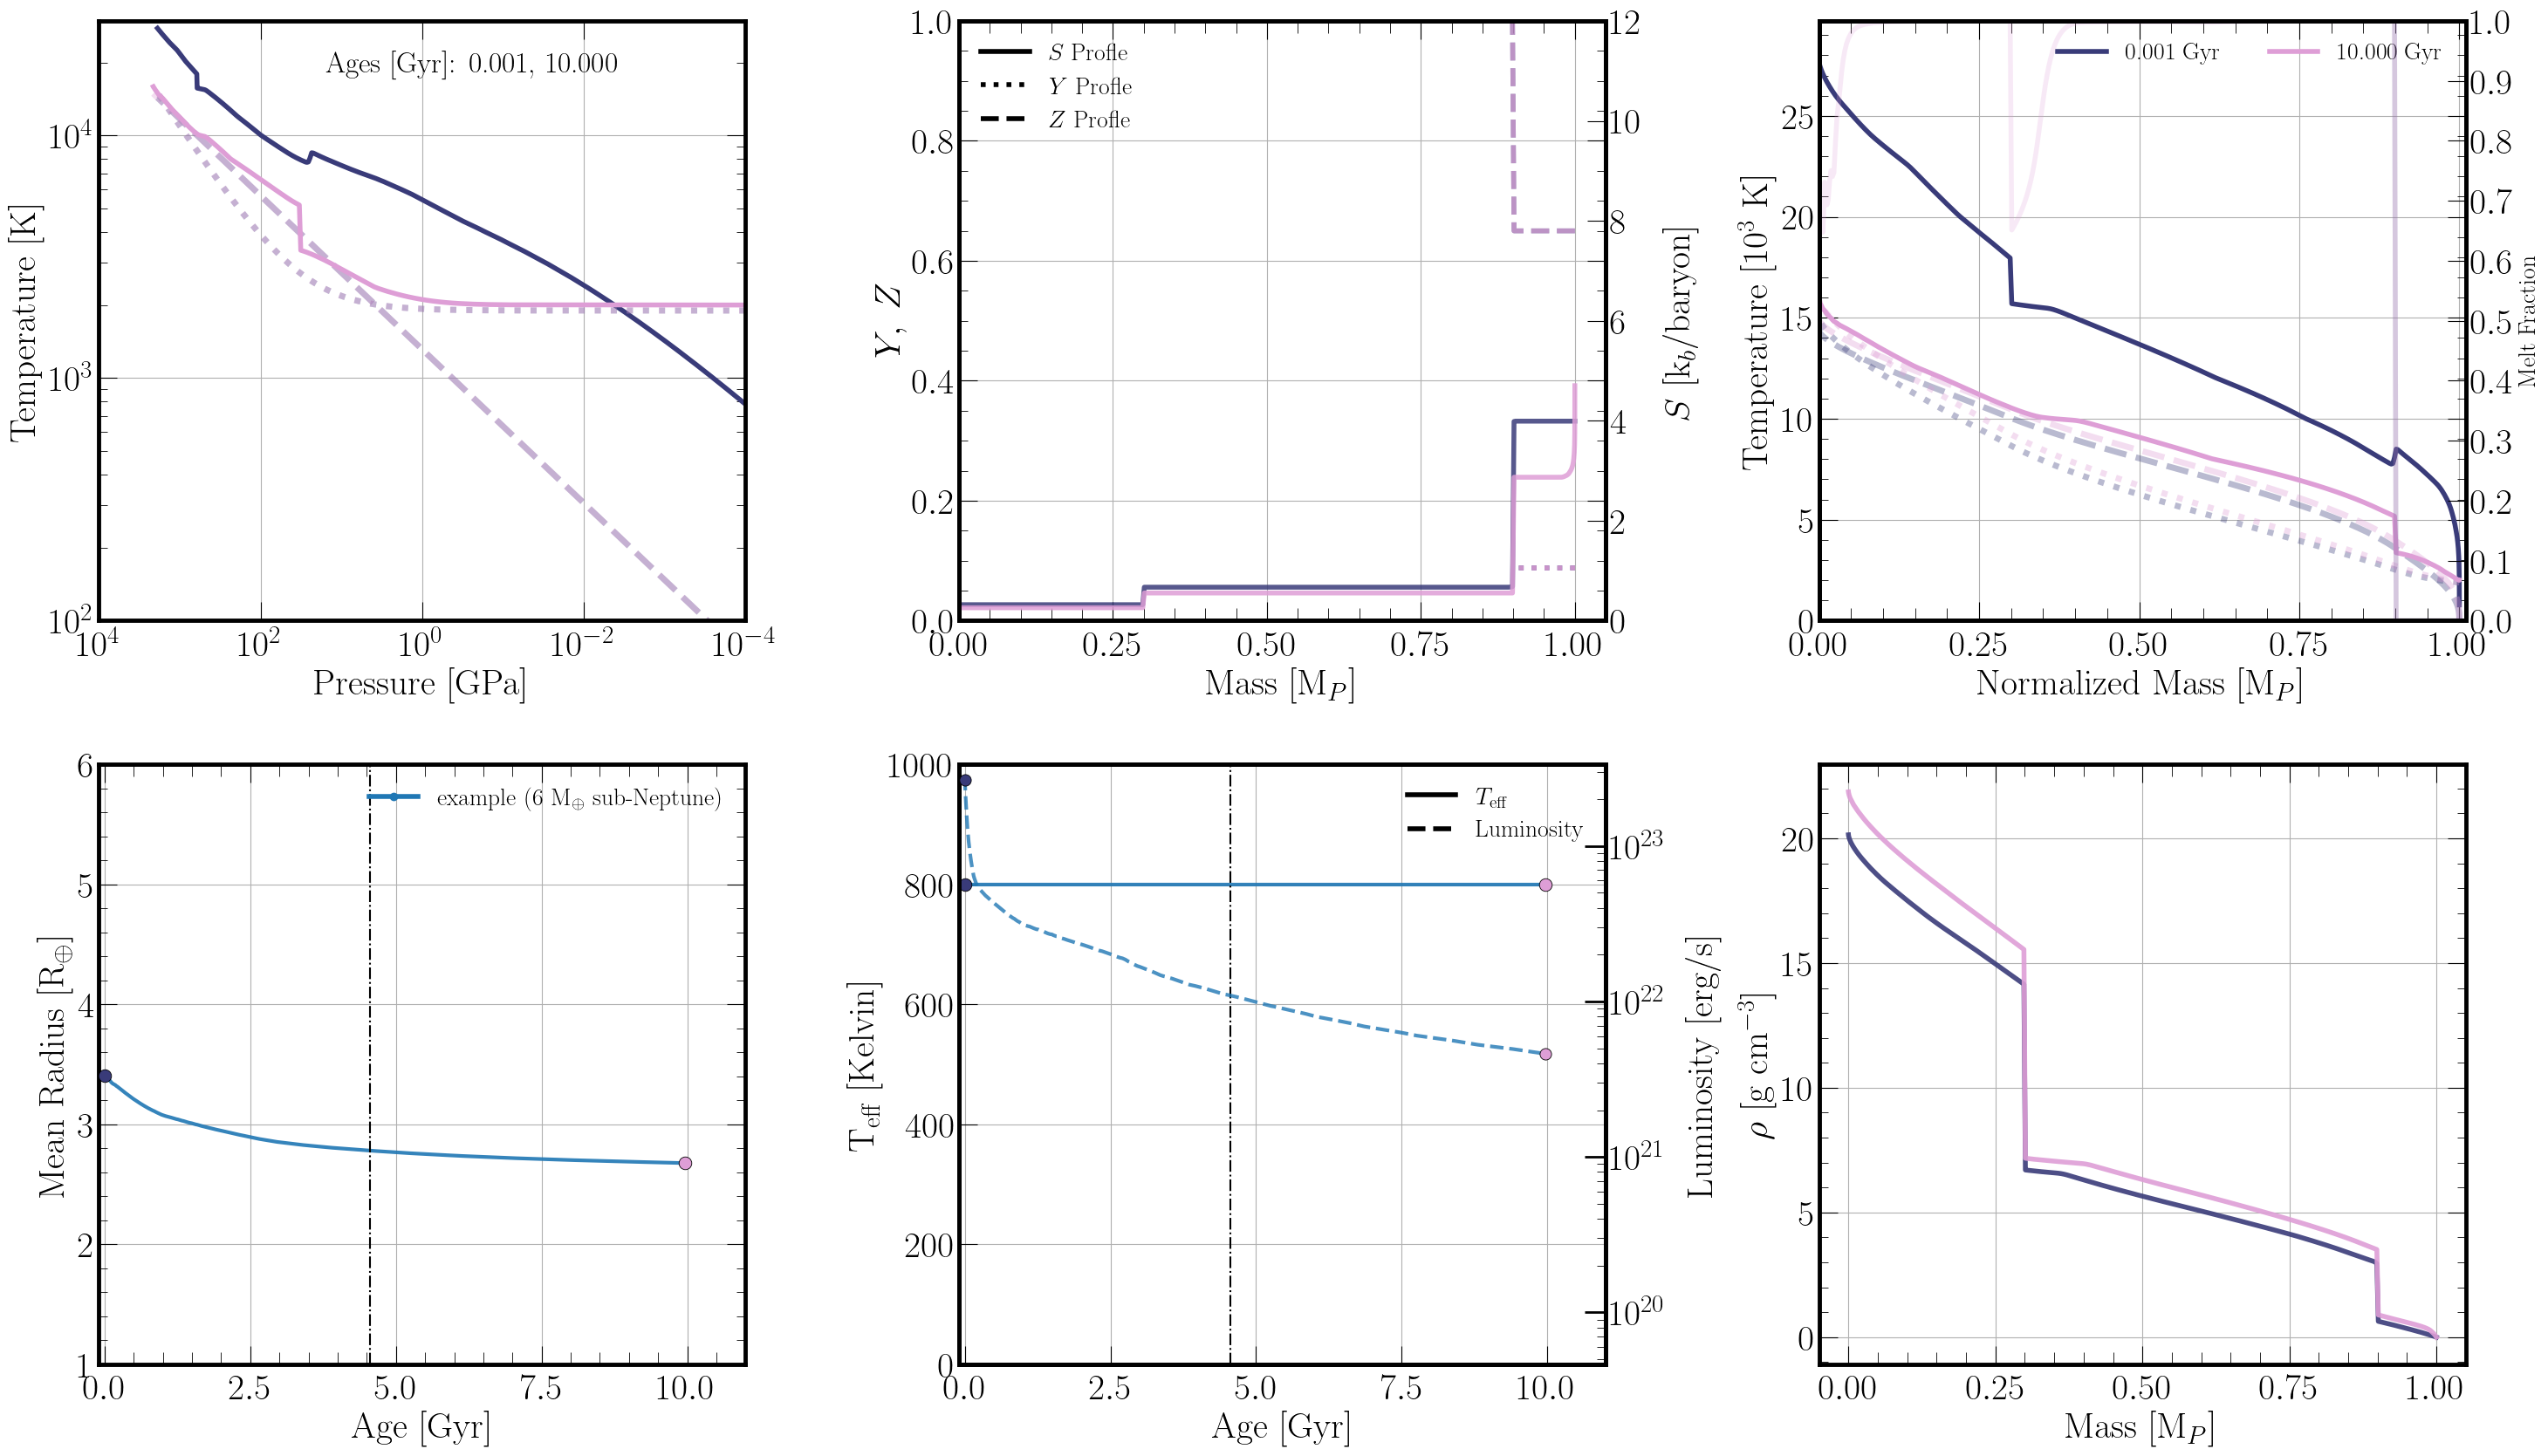

In [1]:
import plot_class

paths = [
    'parameter_examples/parameter_user_sub_neptune_6Mearth_example.ini',
]

init = plot_class.init_plot(paths = paths,
            plot_rock_phases=True,
)

# specify legend labels for each model (in order of paths list)
labels = [
    r'example (6 M$_\oplus$ sub-Neptune)',
]

init.age_plot(
    ages=[0.001, 10.0], # input ages to plot (in Gyr)
    output_file='age_compare',
    labels=labels,
    save=False,
    leg_size=20,
    rad_temp_plot=False, # plotting liquid rock fraction instead
    panel_num=6,
    cmap='tab20b'
)

As observed here, the mantle barely cools throughout the evolution. This effect was discussed in Tejada Arevalo et al. (2026). Because the envelope is only ~10% of the planet's mass, the planet contracts quickly and reaches its equilibrium temperature within 0.01 Gyrs.

The convective core remains liquid because it remains above the iron melt curve (dotted line).

The faint solid curves in the temperature vs. mass plot (upper right corner) are the liquid fractions, where 1.0 is fully liquid and 0.0 is fully solid. A solid iron core is beginning to form at 10 Gyrs.

# 10 M$_\oplus$ sub-Neptune example

Now we increase the mass to 10 M$_\oplus$ using [`parameter_examples/parameter_user_sub_neptune_10Mearth_example.ini`](../parameter_examples/parameter_user_sub_neptune_10Mearth_example.ini). Compared to the 6 M$_\oplus$ case, the .ini sets `M_Mearth = 10.0`, `mass_core = 9.0`, and `mass_core_fe = 3.0`, the rest of the configuration (`T_eq = 800`, `Z_ini = 0.65`, `mantle_entropy = 0.67`) is the same as above.

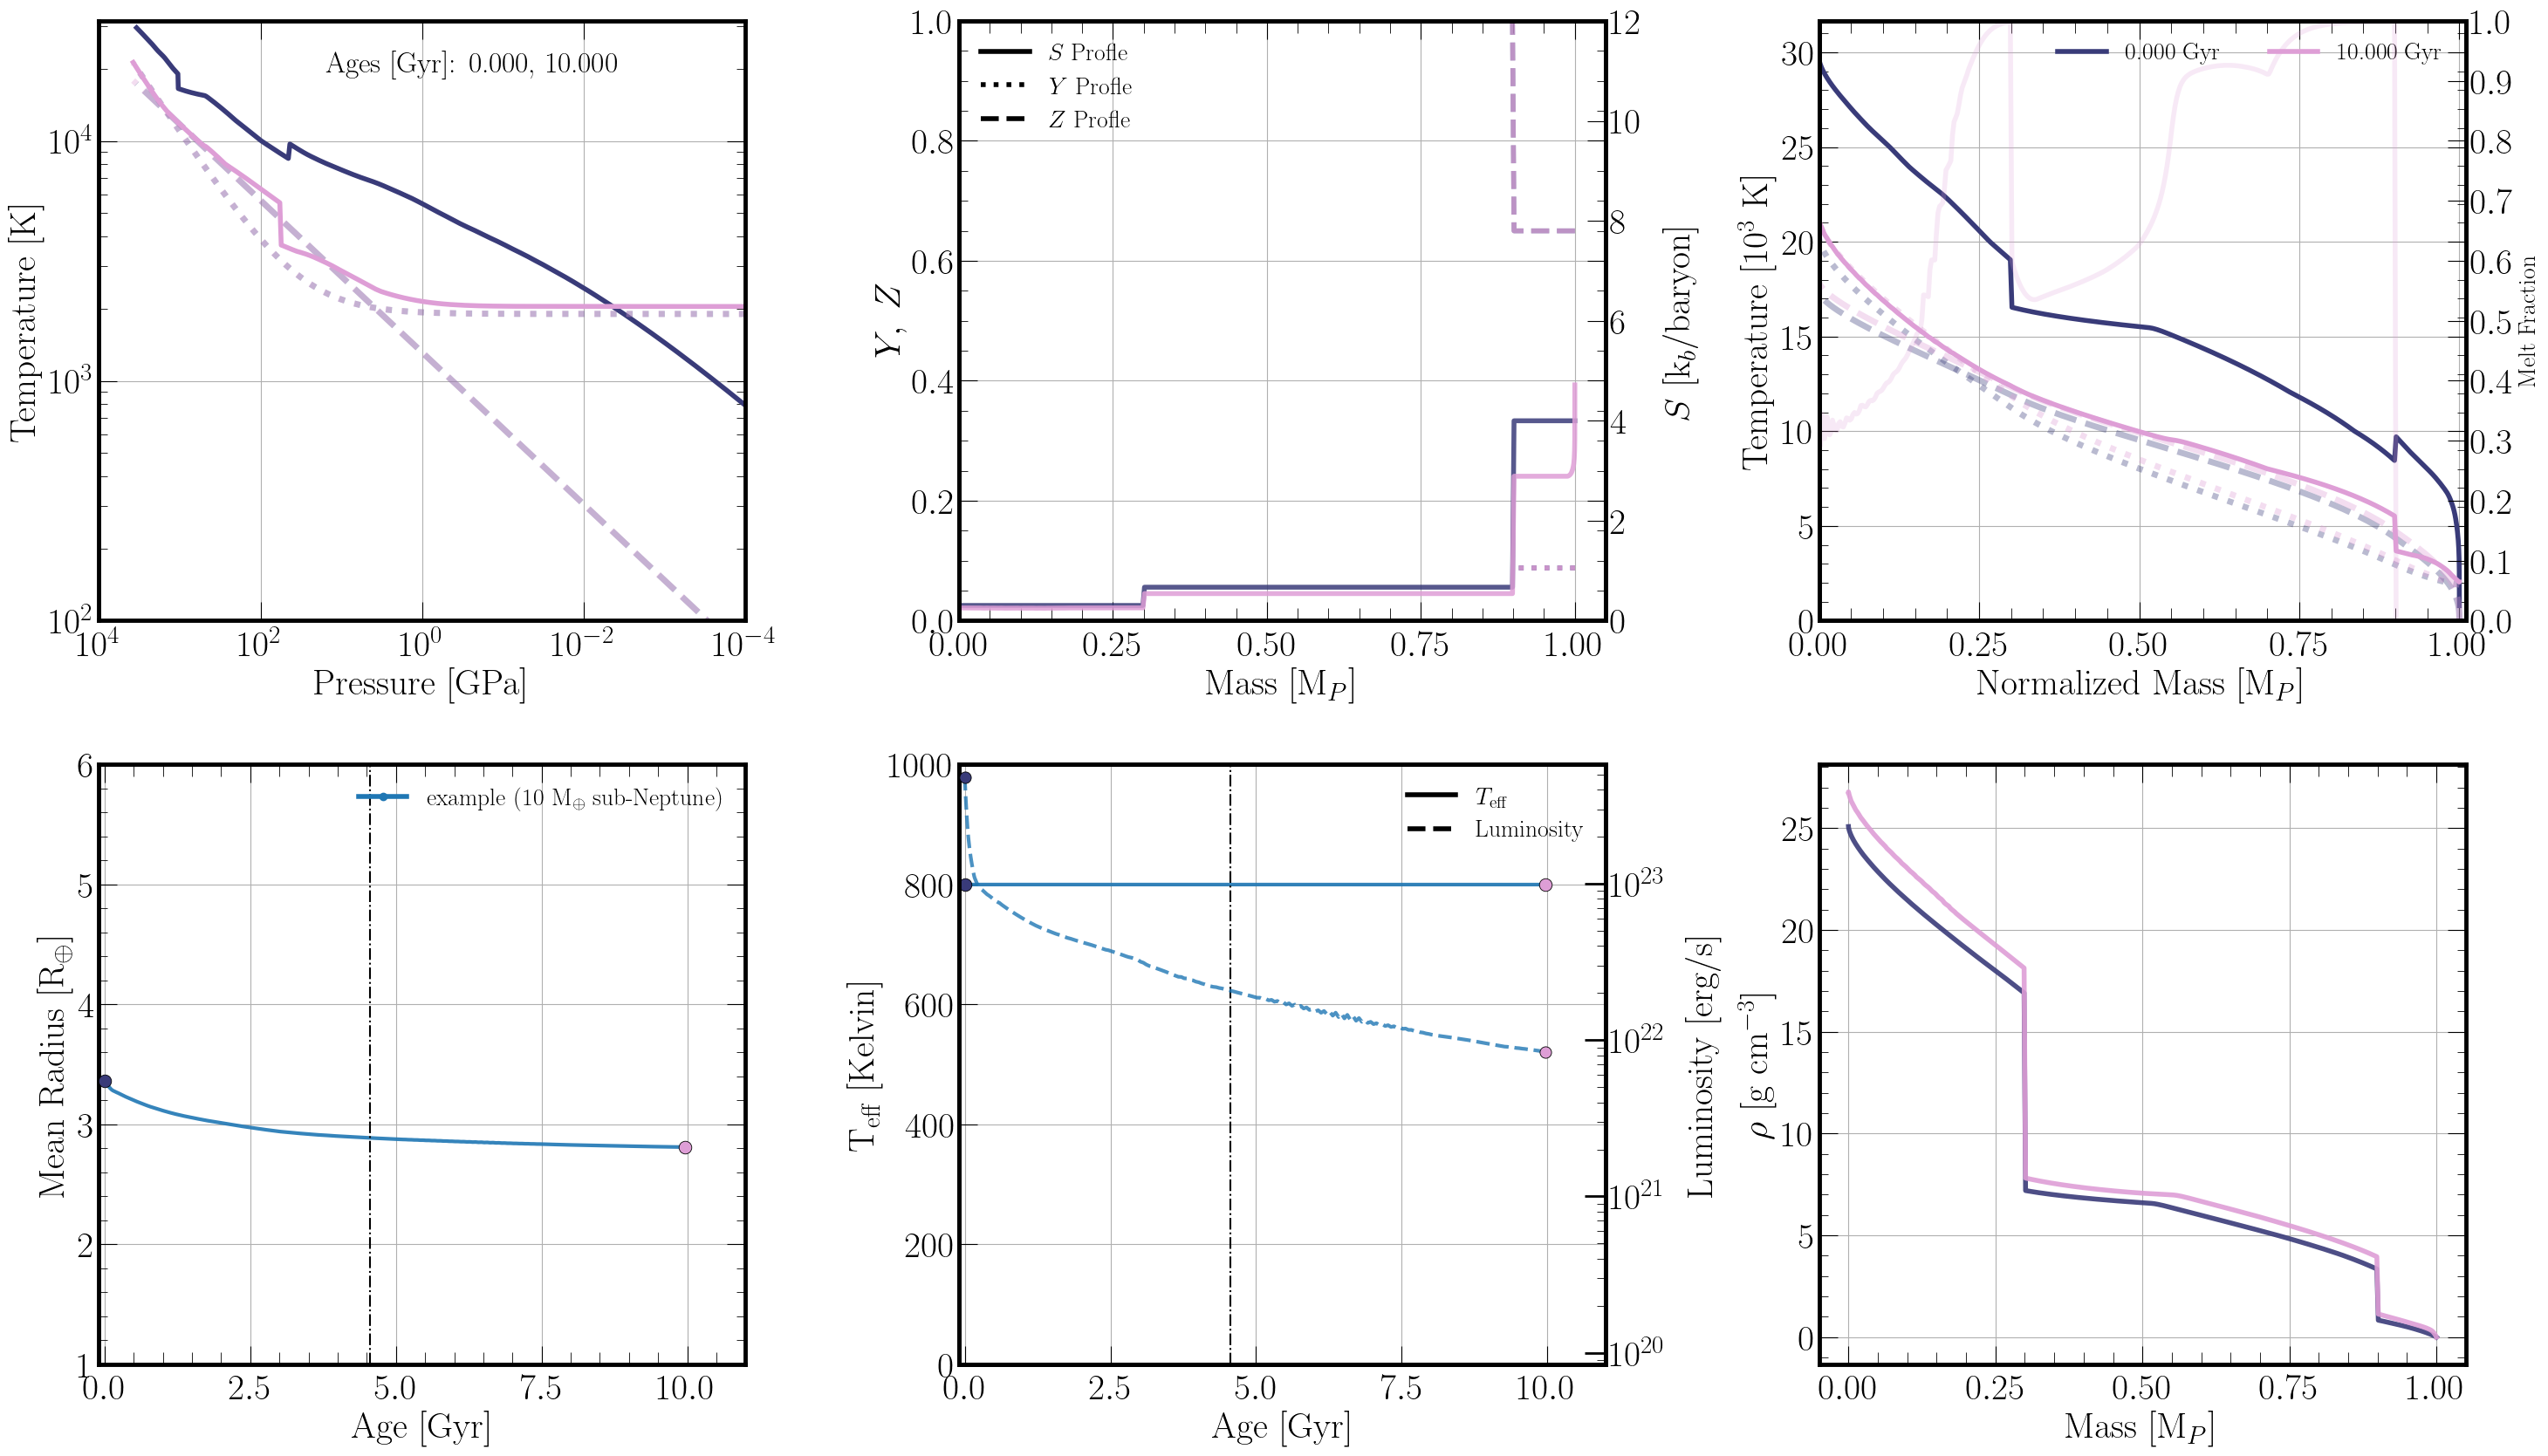

In [2]:
import plot_class

paths = [
    'parameter_examples/parameter_user_sub_neptune_10Mearth_example.ini'
]

init = plot_class.init_plot(paths = paths,
            plot_rock_phases=True,
)

# specify legend labels for each model (in order of paths list)
labels = [
    r'example (10 M$_\oplus$ sub-Neptune)',
]

init.age_plot(
    ages=[0.0, 10.0], # input ages to plot (in Gyr)
    output_file='age_compare',
    labels=labels,
    save=False,
    leg_size=20,
    rad_temp_plot=False,
    panel_num=6,
    cmap='tab20b'
)

Note that the iron melt curve (black dotted curve) intercepts the temperature profile of the iron core, as seen in the upper left hand corner. 

The iron melt curve is higher than the silicate melt curve at pressures lower than 5 GPa, and the temperature becomes lower than that of silicate melt at pressures above. At pressures close to a TPa, however, the melt curve steepens. This means that for sub-Neptunes and super-Earths of higher mass, and thus higher central pressures, their cores may become solid as their pressure increases, while sub-Neptunes of lower mass could harbor a liquid core.

# Sub-Neptunes or super-Earths with thin envelopes

Unlike the sub-Neptune structures above, we can also model planets with very thin H-He envelopes. The example .inis in this section keep an envelope of about 0.01% by mass (e.g., `mass_core = 0.9999` for a 1 M$_\oplus$ planet).

We specify a semi-gray atmosphere attached to the 1-bar surface by setting `bc_atm = gray` and `planet = Super_Earth`. We add a thin H-He layer here. Below are several 1 to 10 Earth mass examples with this thin envelope. Given the low envelope metallicity (`Z_ini = 0.00017`), we use `rock_gray_kappa_ir = 1e-3` cm$^2$/g as the gray IR opacity.

These thinenv runs all use `T_eq = 255` K (a cold rocky planet baseline; nothing about the gray atmosphere itself fixes this; it is just the value chosen in the example .inis).

## Semi-gray radiative atmosphere for rocky planets


For rocky planets without a significant gaseous envelope (super-Earths modelled
with  `bc_atm = 'gray'`), a detailed atmosphere table is unavailable or
unnecessary. Instead, the model uses a semi-gray, Eddington-approximation
atmosphere to translate the temperature at the top of the interior grid
($T_\mathrm{surf}$) into two quantities the thermal evolution needs:

*  $T_\mathrm{int}$: the intrinsic temperature, which sets the
          luminosity radiated from the planet's interior,

* $T_\mathrm{eff}$: the total effective temperature, including
          reprocessed stellar irradiation.

In a plane-parallel, gray (wavelength-independent opacity) atmosphere in
radiative equilibrium, the Eddington approximation gives the temperature
profile as a function of optical depth $\tau$:
\begin{equation}
    T^4(\tau) = \frac{3}{4} T_\mathrm{eff}^4 \left(\tau + \frac{2}{3}\right).
\end{equation}
The total effective temperature separates into an irradiation term and an
intrinsic term:
\begin{equation}
    T_\mathrm{eff}^4 = T_\mathrm{int}^4 + T_\mathrm{eq}^4,
\end{equation}
where $T_\mathrm{eq}$ is the planet's equilibrium temperature set by the
stellar irradiation and bond albedo. Substituting, the temperature at any
depth is
\begin{equation}
    T^4(\tau) = T_\mathrm{eq}^4
        + \frac{3}{4} T_\mathrm{int}^4 \left(\tau + \frac{2}{3}\right).
\end{equation}

\subsection*{Matching to the Interior}

Rather than solving the full atmosphere structure, the model evaluates the
relation above at a single \emph{matching pressure} $P_\mathrm{match}$, the
pressure level at which the atmosphere is stitched to the interior grid. The
corresponding IR optical depth is
\begin{equation}
    \tau_\mathrm{match} = \frac{\kappa_\mathrm{IR}\, P_\mathrm{match}}{g},
\end{equation}
where $\kappa_\mathrm{IR}$ is the (gray) IR opacity in $\mathrm{cm^2\,g^{-1}}$
and $g$ is the surface gravity. This is the standard hydrostatic relation
$d\tau = \kappa\,\rho\,dr$ integrated assuming $dP = -\rho g\,dr$.

Setting $T(\tau_\mathrm{match}) = T_\mathrm{surf}$ and inverting for
$T_\mathrm{int}$ gives:
\begin{equation}
    T_\mathrm{int}^4
        = \frac{\max\!\left(T_\mathrm{surf}^4 - T_\mathrm{eq}^4,\; 0\right)}
               {\dfrac{3}{4}\!\left(\tau_\mathrm{match} + \dfrac{2}{3}\right)},
\end{equation}
where the $\max(\cdot, 0)$ floor ensures $T_\mathrm{int}$ remains real when
the planet is in thermal equilibrium with its star ($T_\mathrm{surf} \leq
T_\mathrm{eq}$). The total effective temperature follows immediately:
\begin{equation}
    T_\mathrm{eff} = \left(T_\mathrm{int}^4 + T_\mathrm{eq}^4\right)^{1/4}.
\end{equation}

The intrinsic luminosity driving the planet's cooling is
\begin{equation}
    L_\mathrm{int} = 4\pi R^2\, \sigma_\mathrm{SB}\, T_\mathrm{int}^4,
\end{equation}
which enters the energy equation as the surface boundary condition. In the
Newton--Raphson Jacobian the required sensitivity of the surface flux to the
surface temperature is obtained by differentiating equation~\eqref{eq:Tint}:
\begin{equation}
    \frac{\partial F_\mathrm{int}}{\partial T_\mathrm{surf}}
        = \frac{4\,\sigma_\mathrm{SB}\, T_\mathrm{surf}^3}
               {\dfrac{3}{4}\!\left(\tau_\mathrm{match} + \dfrac{2}{3}\right)}
    \qquad (T_\mathrm{surf} > T_\mathrm{eq}),
\end{equation}
and zero otherwise. This derivative is chained with $\partial T_\mathrm{surf}/
\partial S = T_\mathrm{surf}/c_P$ (the thermodynamic identity at fixed
pressure) to yield $\partial F_\mathrm{surf}/\partial S$, which populates the
top row of the Jacobian.

**NOTE**: If you see rejected timesteps in these evolution models, that's okay. These models incorporate latent heat and core solidification processes, and sometimes the code needs to re-evaluate a thermal update to keep the errors down.

# 1 M$_\oplus$ thin envelope example

The envelope mass fraction here is 0.01% (`mass_core = 0.9999` of `M_Mearth = 1.0`). Again, a 1 Earth mass planet is technically not a "Super-Earth," but we put it in this category for comparison purposes.

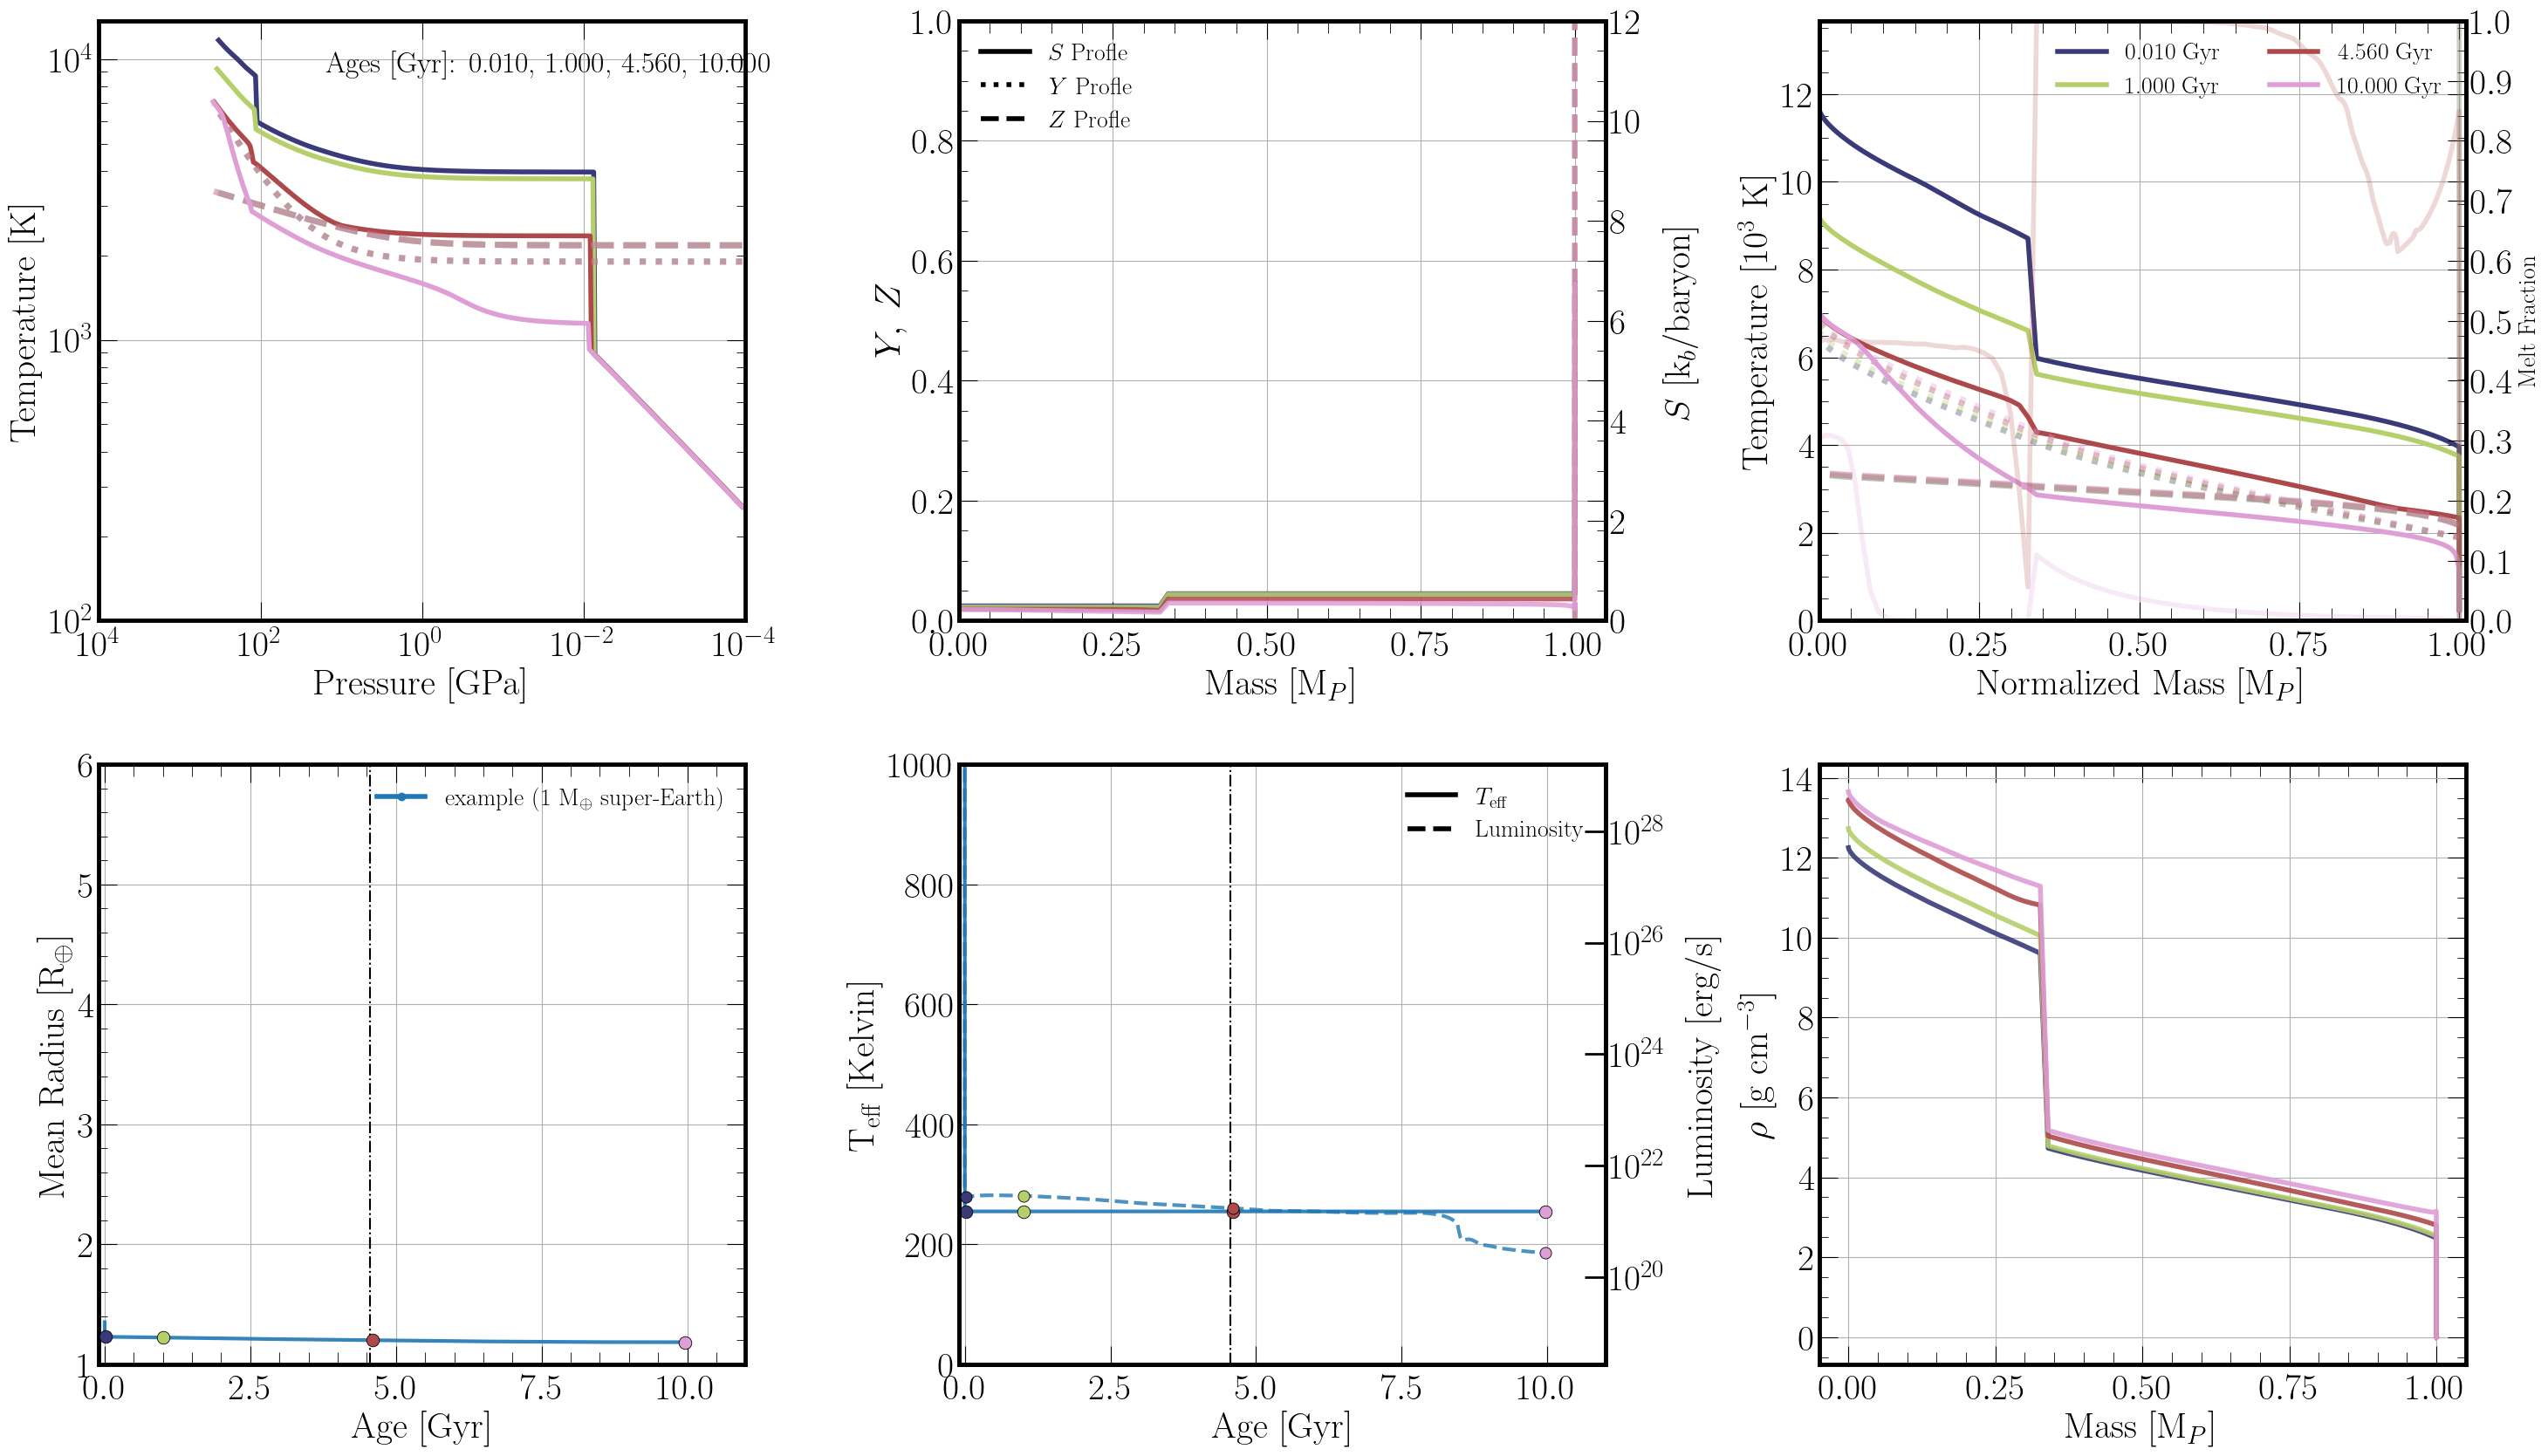

In [3]:
import plot_class

paths = [
    'parameter_examples/parameter_user_super_earth_1Mearth_thinenv_example.ini',
]

init = plot_class.init_plot(paths = paths,
            plot_rock_phases=True,
)

# specify legend labels for each model (in order of paths list)
labels = [
    r'example (1 M$_\oplus$ super-Earth)',
]

init.age_plot(
    ages=[0.01, 1.0, 4.56, 10], # input ages to plot (in Gyr)
    output_file='age_compare',
    labels=labels,
    save=False,
    leg_size=20,
    rad_temp_plot=False,
    panel_num=6,
    cmap='tab20b'
)

**NOTE**: Unlike its bare-atmosphere counterpart, its mantle remains much hotter, and a solid inner iron core has emerged (upper-right) below a liquid iron core. In addition, its 1-bar mean radius has nearly doubled due to a high equilibrium temperature and heat from the envelope-mantle boundary. Remember, this is a simple H-He envelope. 

## 3 M$_\oplus$ example

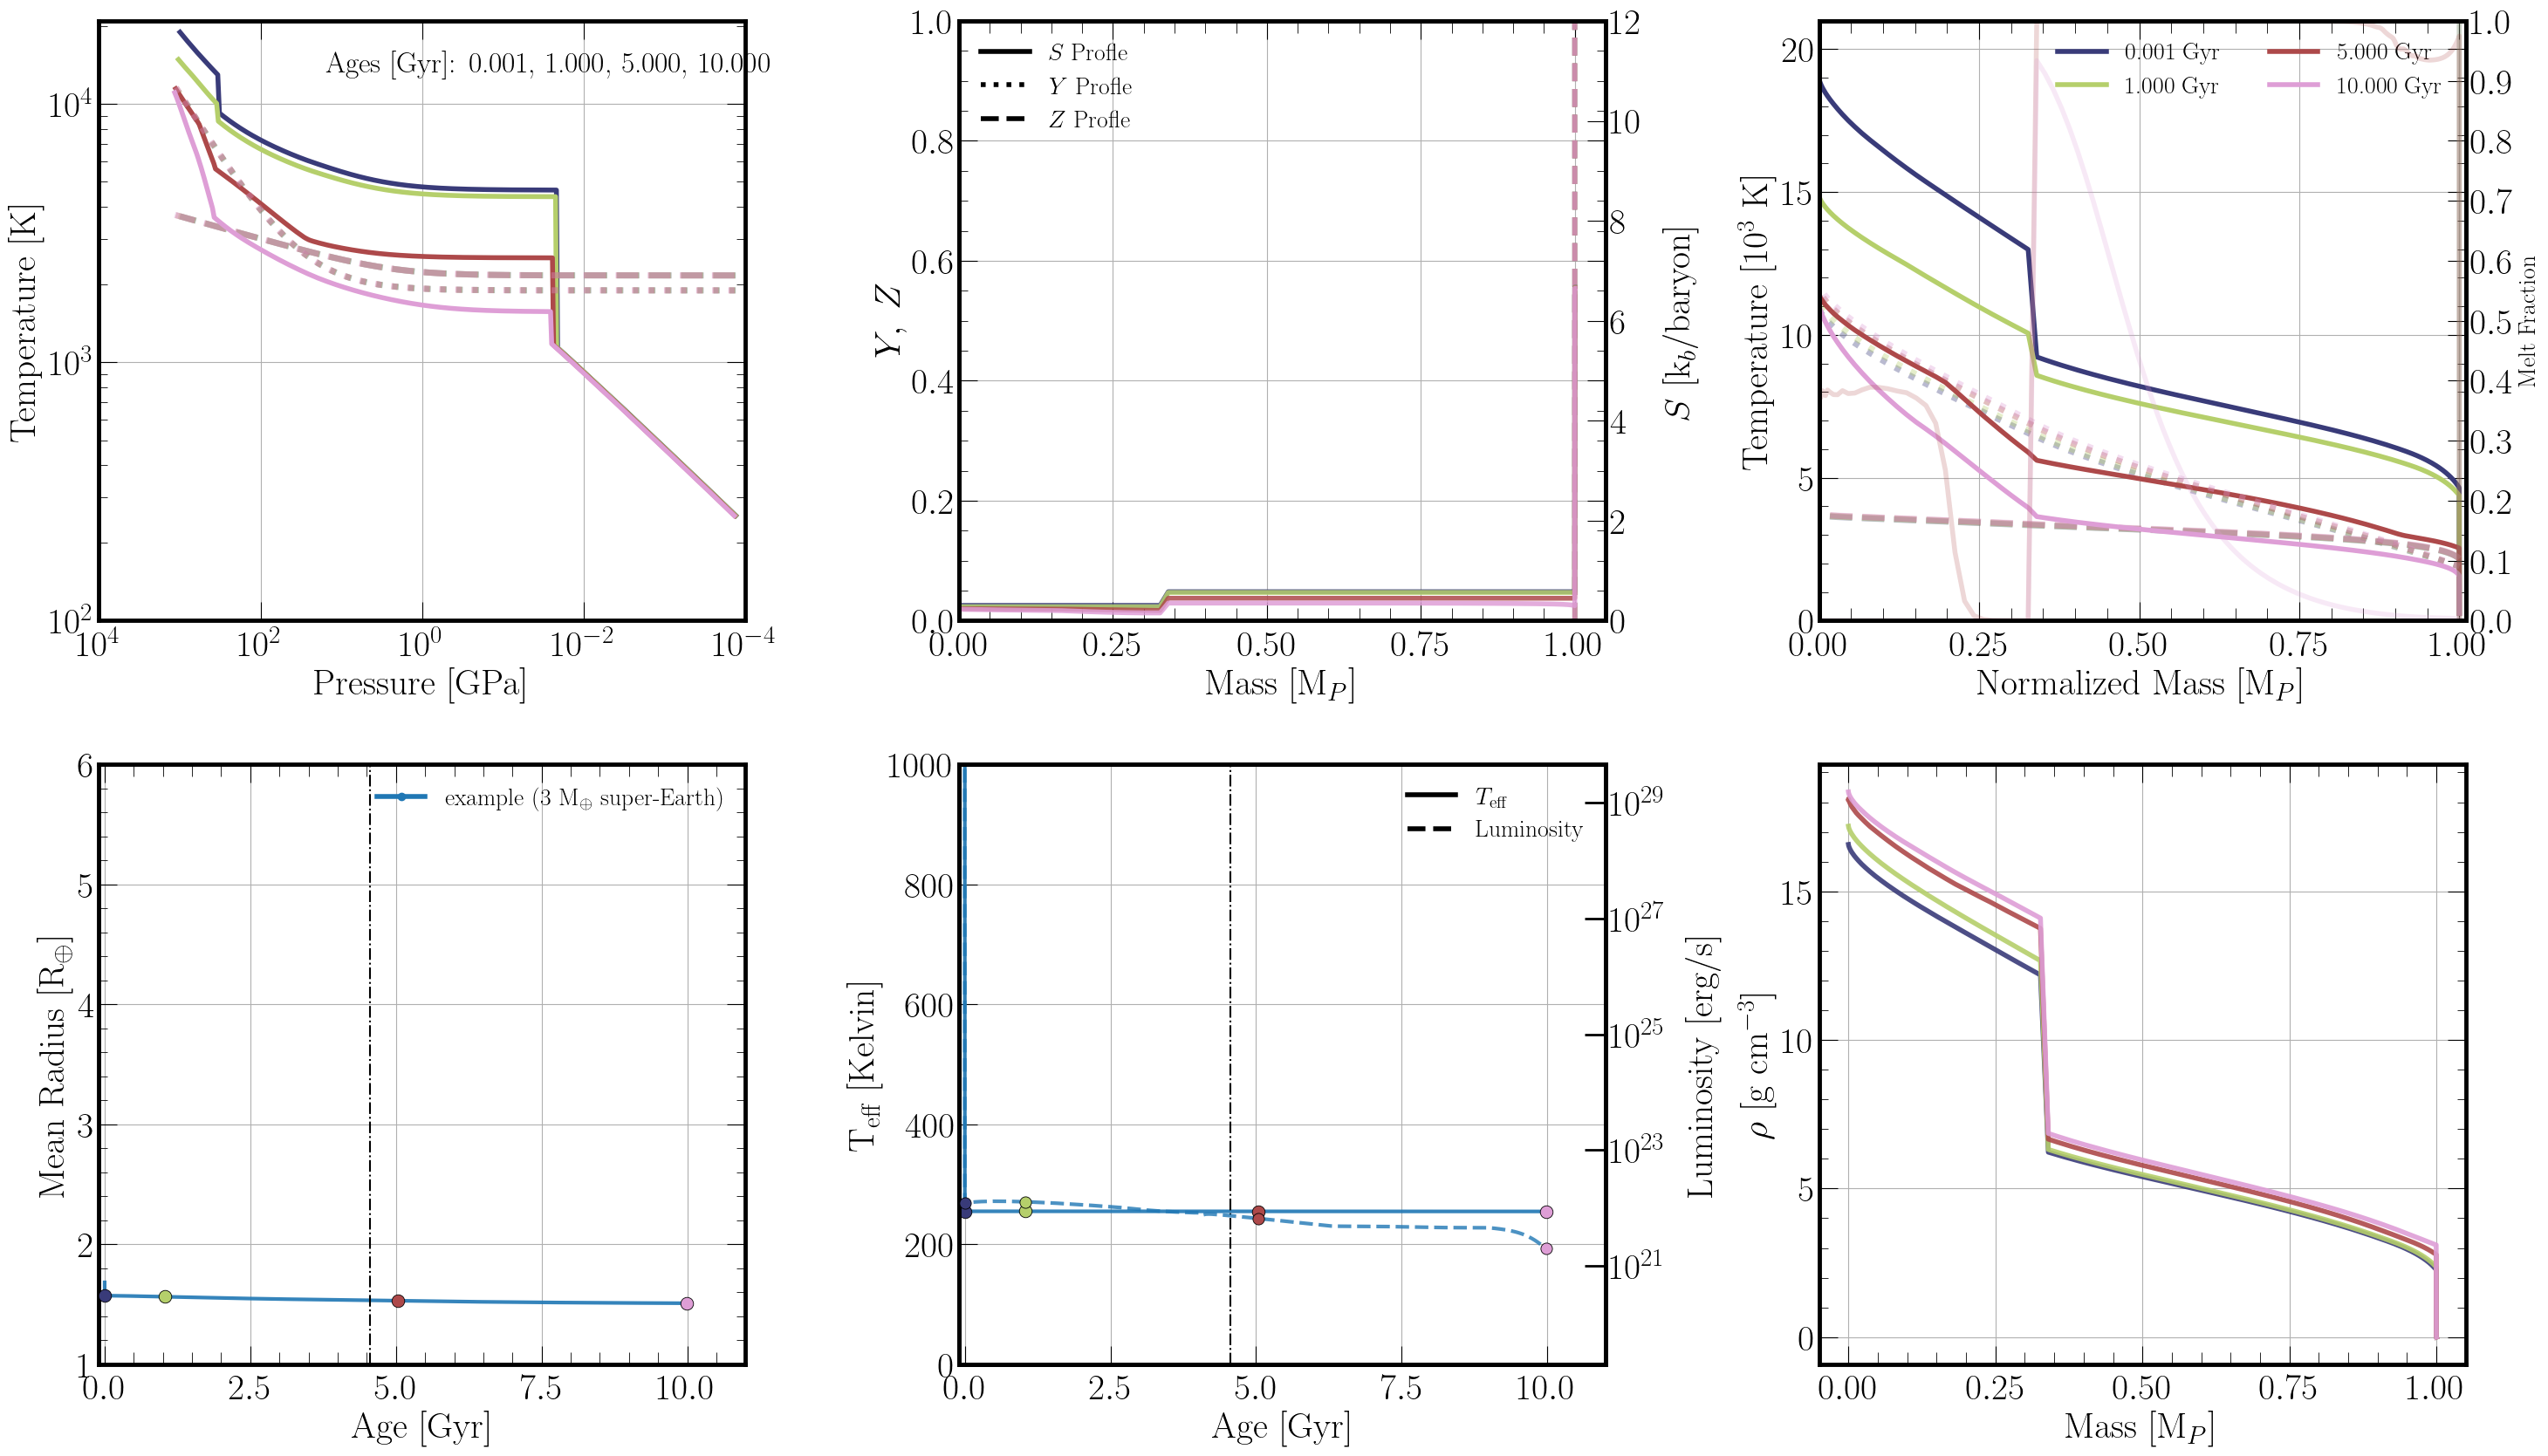

In [4]:
import plot_class

paths = [
    'parameter_examples/parameter_user_super_earth_3Mearth_thinenv_example.ini',

]

init = plot_class.init_plot(paths = paths,
            plot_rock_phases=True,
)

# specify legend labels for each model (in order of paths list)
labels = [
    r'example (3 M$_\oplus$ super-Earth)',
]

init.age_plot(
    ages=[0.001, 1.0, 5.0, 10], # input ages to plot (in Gyr)
    output_file='age_compare',
    labels=labels,
    save=False,
    leg_size=20,
    rad_temp_plot=False,
    panel_num=6,
    cmap='tab20b'
)

## 5 M$_\oplus$ example

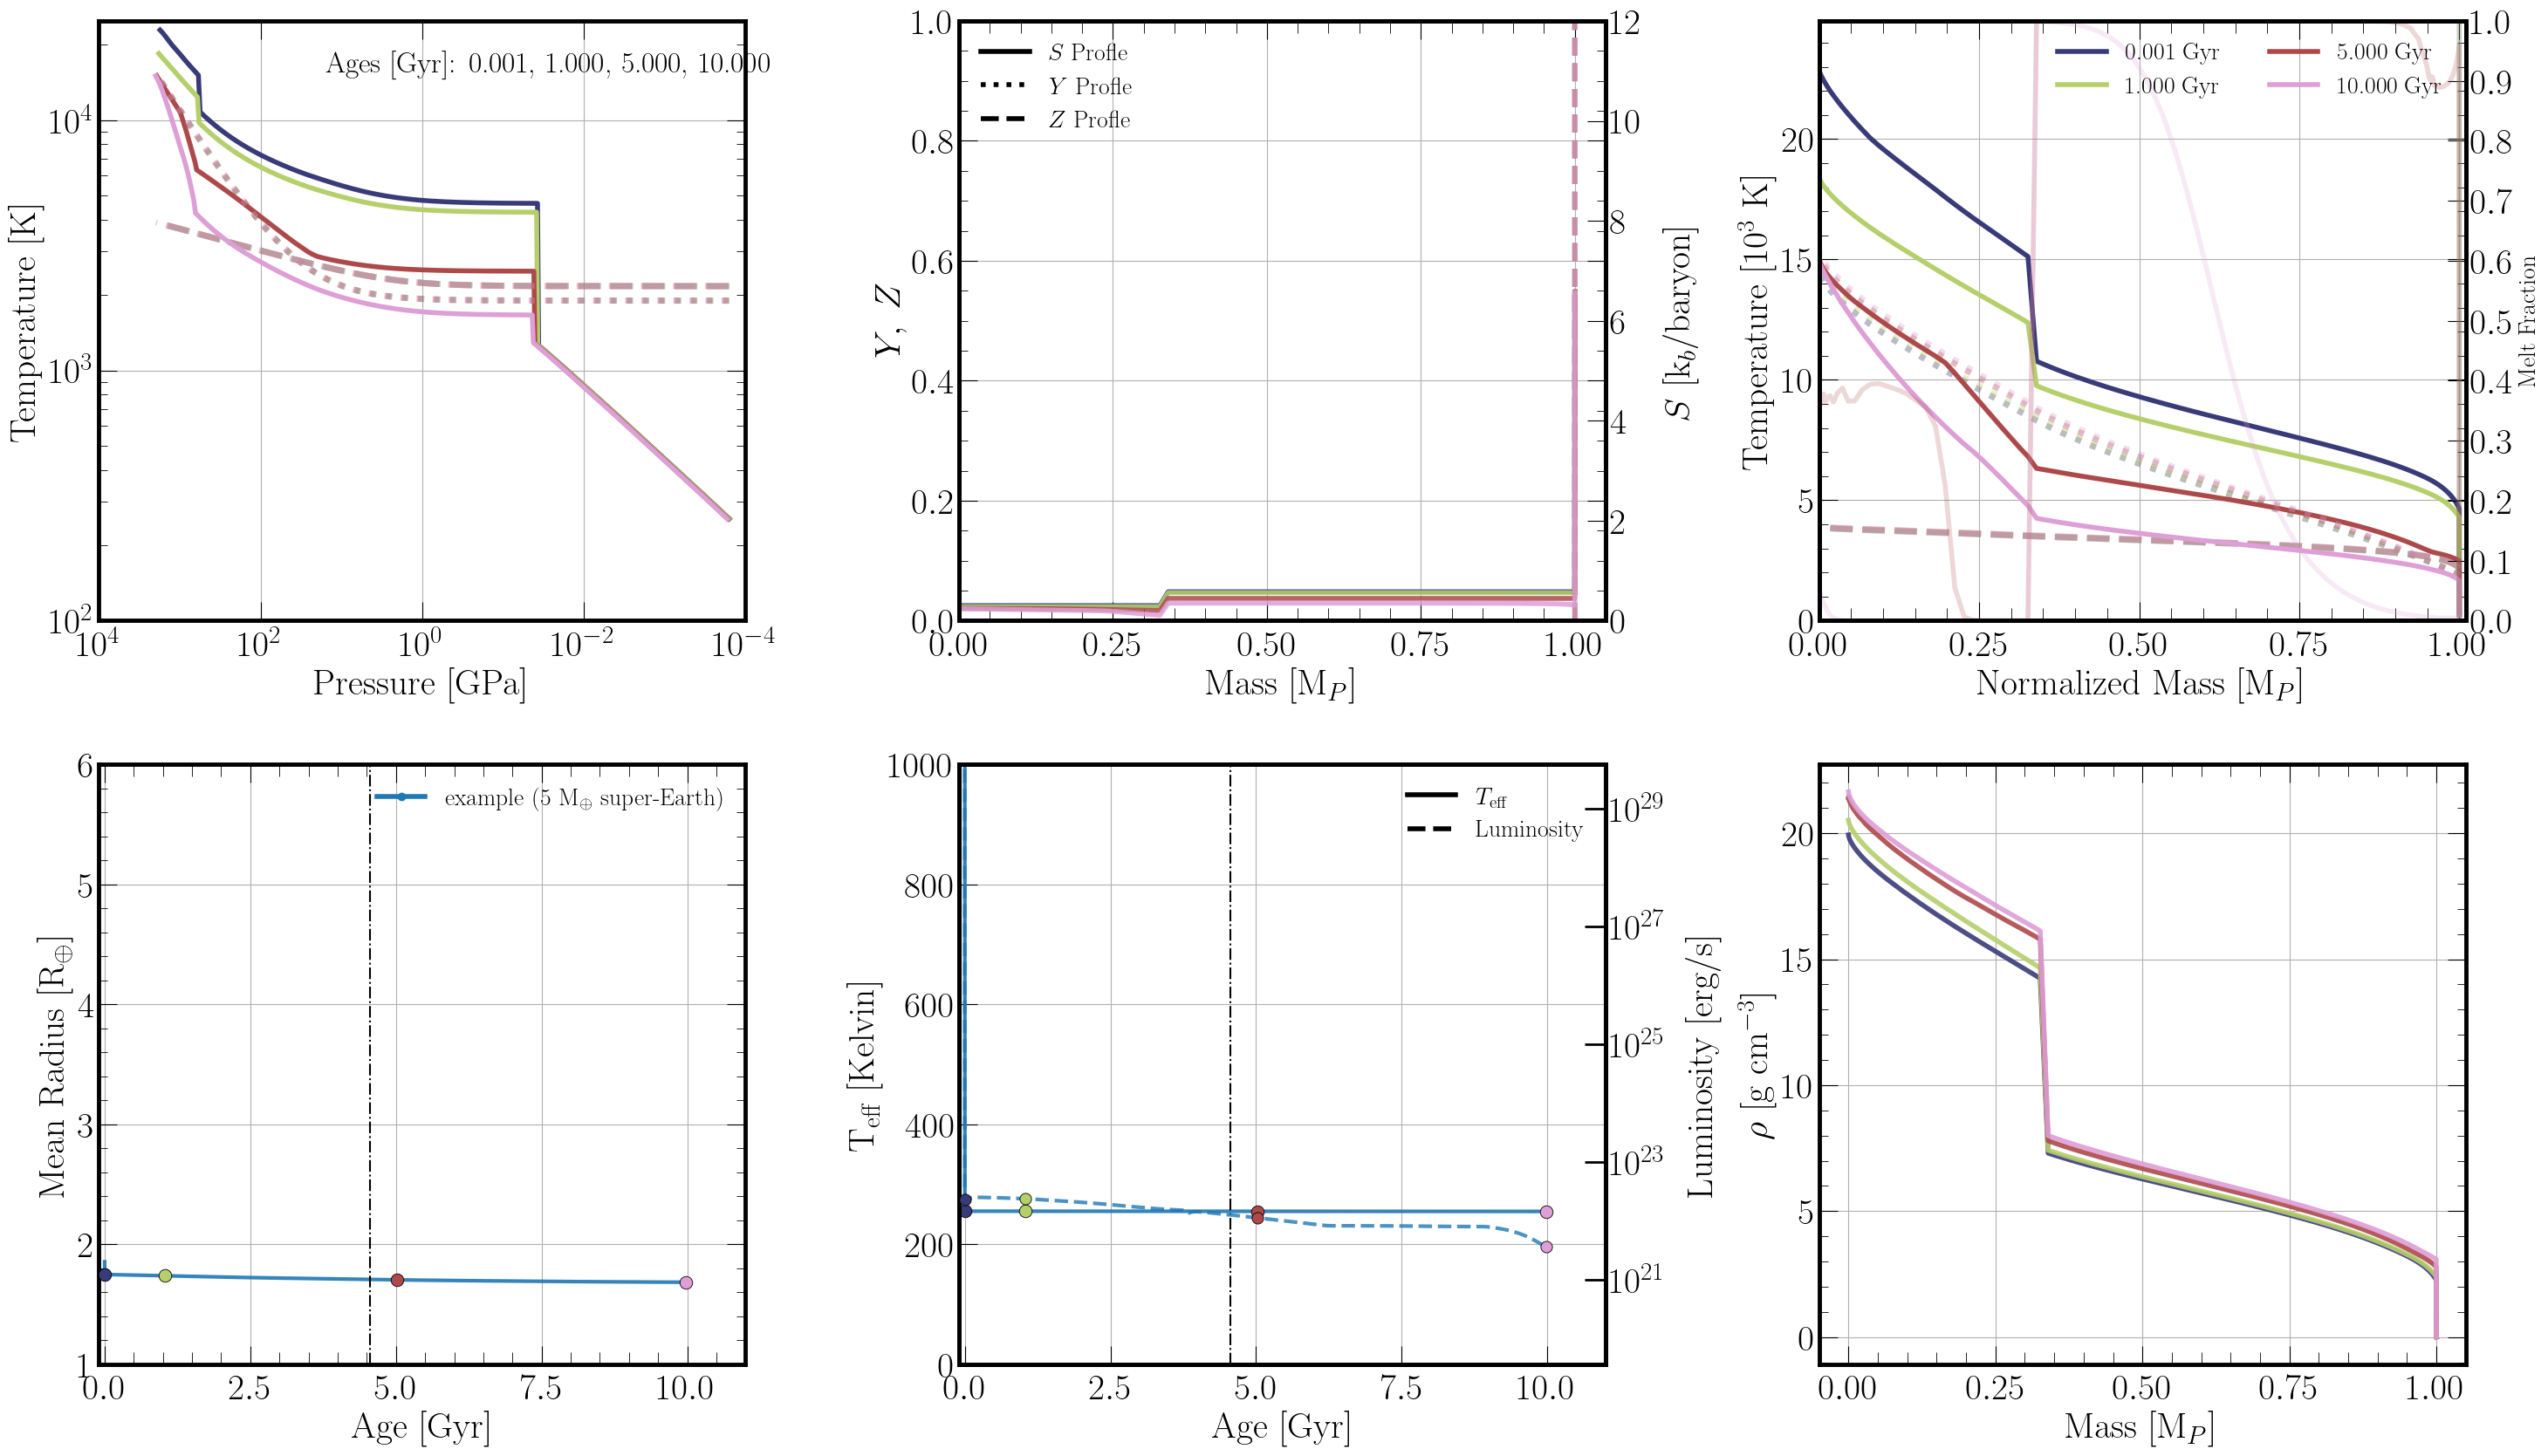

In [5]:
import plot_class

paths = [
    'parameter_examples/parameter_user_super_earth_5Mearth_thinenv_example.ini',

]

init = plot_class.init_plot(paths = paths,
            plot_rock_phases=True,
)

# specify legend labels for each model (in order of paths list)
labels = [
    r'example (5 M$_\oplus$ super-Earth)',
]

init.age_plot(
    ages=[0.001, 1.0, 5.0, 10.0], # input ages to plot (in Gyr)
    output_file='age_compare',
    labels=labels,
    save=False,
    leg_size=20,
    rad_temp_plot=False,
    panel_num=6,
    cmap='tab20b'
)

## 10 M$_\oplus$ example

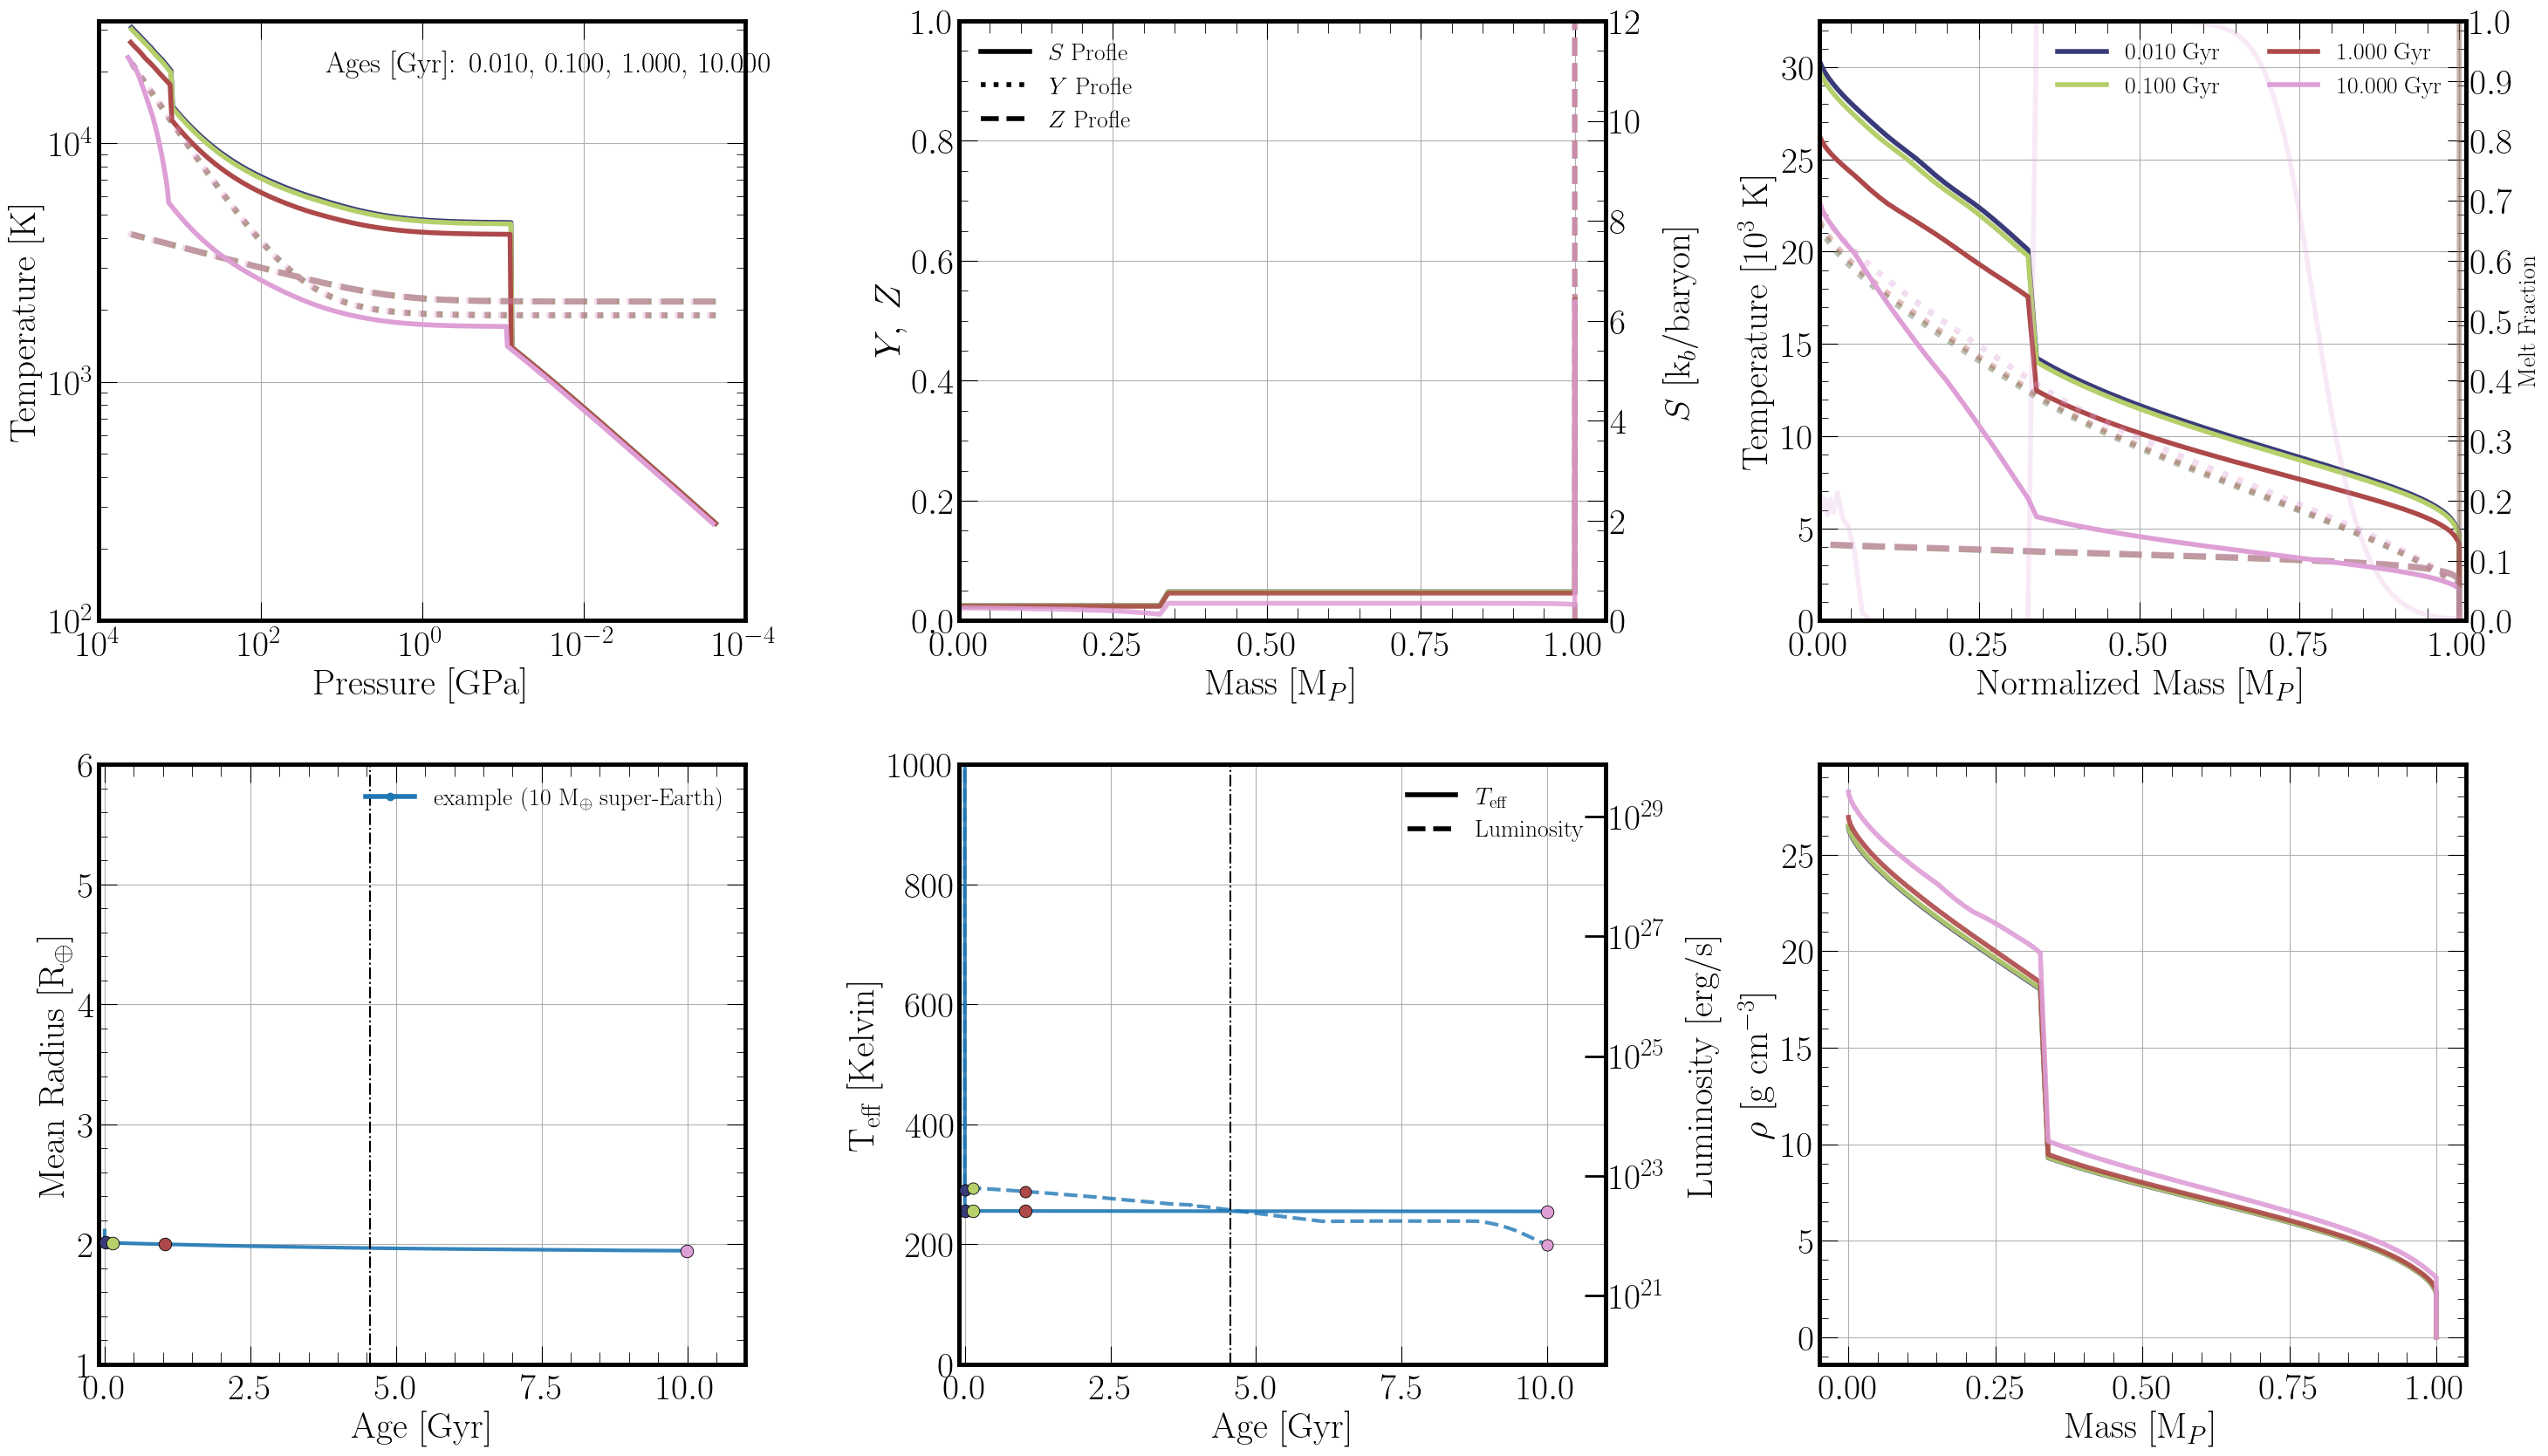

In [6]:
import plot_class

paths = [
    'parameter_examples/parameter_user_super_earth_10Mearth_thinenv_example.ini',

]

init = plot_class.init_plot(paths = paths,
            plot_rock_phases=True,
)

# specify legend labels for each model (in order of paths list)
labels = [
    r'example (10 M$_\oplus$ super-Earth)',
]

init.age_plot(
    ages=[0.01, 0.1, 1.0, 10.0], # input ages to plot (in Gyr)
    output_file='age_compare',
    labels=labels,
    save=False,
    leg_size=20,
    rad_temp_plot=False,
    panel_num=6,
    cmap='tab20b'
)

**NOTE**: In these last couple of examples, the thin envelopes are hotter initially than the upper most part of the mantle because I needed to lower the initial mantle entropy for higher mass planets, as explained in the previous section.

# Super-Earth exoplanets without envelopes or atmospheres

Super-Earth exoplanets are defined here as planets without an envelope, so the total mass is the same as the core mass.

Many super-Earth and terrestrial planets have been found to likely not harbor a thick atmosphere, and are consistent with bare rocks (e.g., Kreidberg et al. 2019; Crossfield et al. 2022; Zieba et al. 2023).

To simulate the thermal cooling of these planets, we will use a simple $\sigma T_{\rm{surf}}^4$ boundary condition, where $T_{\rm{surf}}$ is the surface temperature at 1 bar, by selecting `bc_atm = bare`. This way, the planet will lose its thermal energy directly into the vacuum and thus accelerate cooling.

The bare super-Earth example .inis use `T_eq = 255` K throughout, the same value used in the thin-envelope examples above.

## 3 M$_\oplus$ example

We will copy the same 3 earth mass example from above and set `mass_core = 3.0`, so that the envelope fraction is 0.0, and thus the structure will cool as a bare rock with a semi-gray atmosphere model at its surface.

The bare examples here ship with the viscous convection transition turned on (`[core].viscous_mantle_convection = True`; see Tejada Arevalo et al. 2026a, b). This type of convection kicks in when the adiabat crosses the melting curves of Mg$_2$SiO$_4$ and that of iron. You can set it to `False`, rerun the config under a new name, and compare. The differences in the cooling are instructive, and left as an exercise to the reader.

When you run this file, you might notice that many timesteps are rejected. No need for alarm, the code will still finish. 

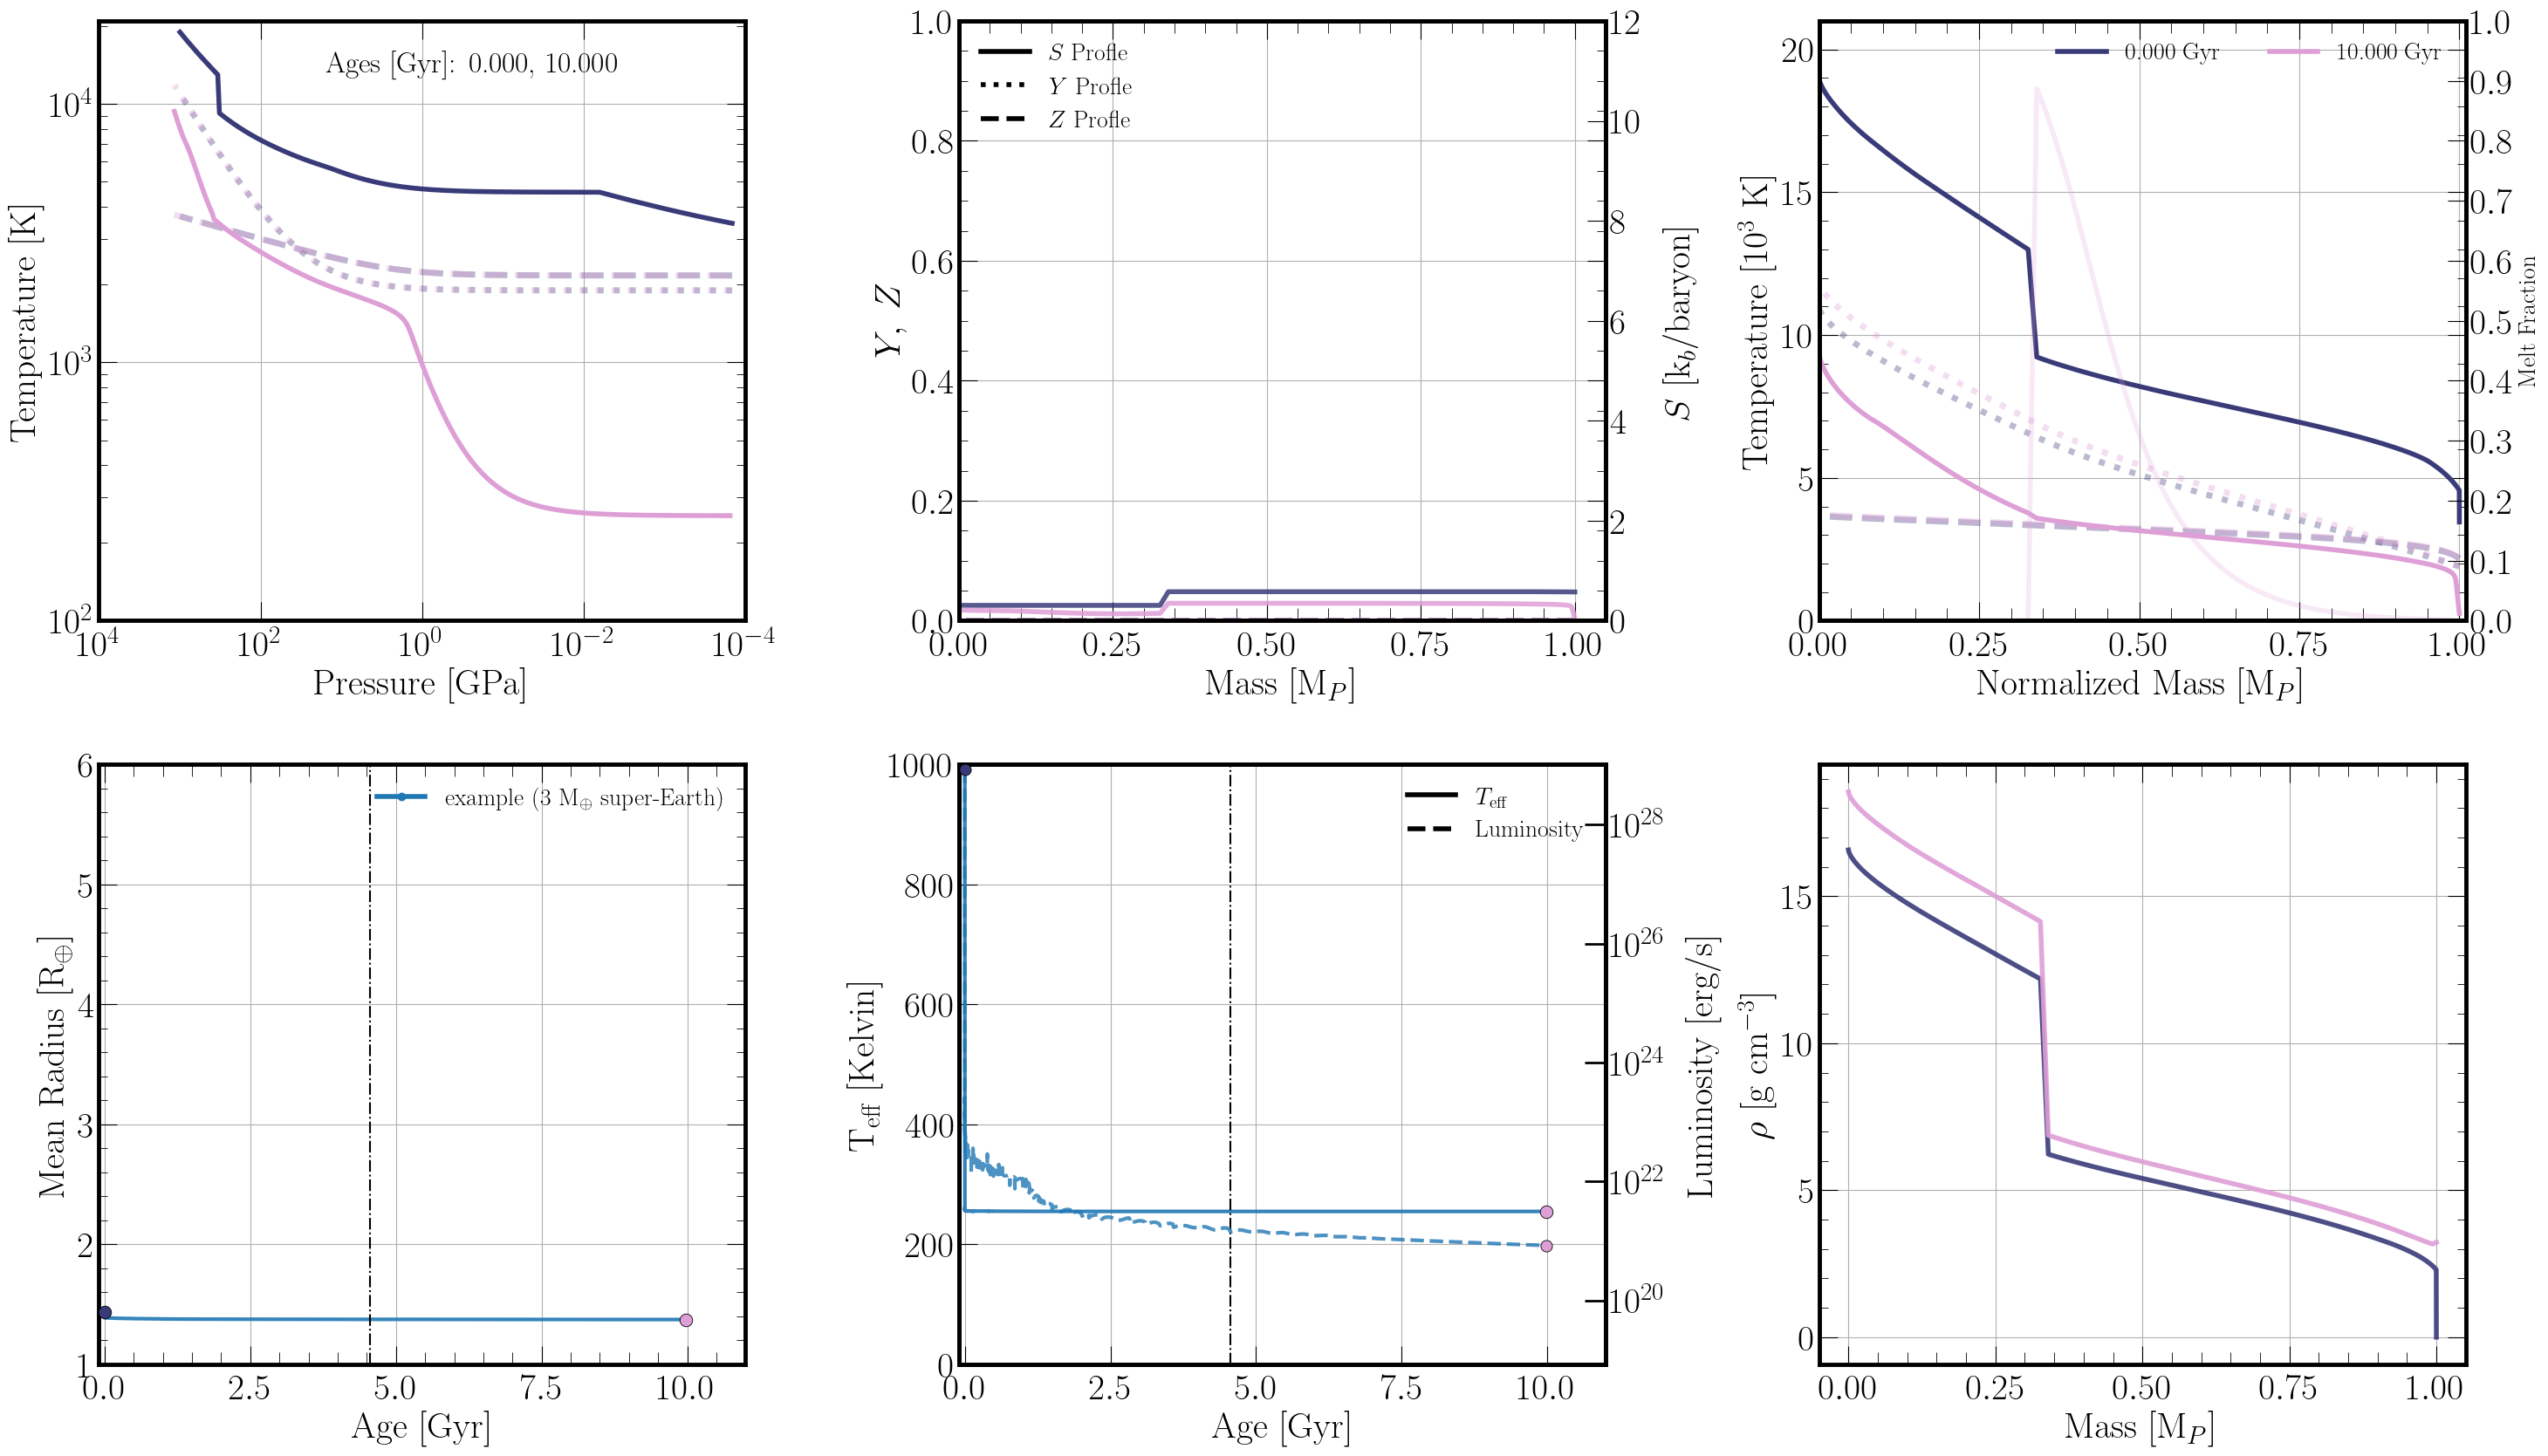

In [7]:
import plot_class

paths = [
    'parameter_examples/parameter_user_super_earth_3Mearth_bare_example.ini',

]

init = plot_class.init_plot(paths = paths,
            plot_rock_phases=True,
)

# specify legend labels for each model (in order of paths list)
labels = [
    r'example (3 M$_\oplus$ super-Earth)',
]

init.age_plot(
    ages=[0.0, 10.0], # input ages to plot (in Gyr)
    output_file='age_compare',
    labels=labels,
    save=False,
    leg_size=20,
    rad_temp_plot=False,
    panel_num=6,
    cmap='tab20b'
)

## 1 M$_\oplus$ example 

While it may sound silly to provide a 1 M_\oplus example in the super-Earth section, we provide it nonetheless for demonstration purposes and to compare across masses in the Mass-Radius (M-R) section later.

**NOTE**: Super-Earth structures cool much faster than the sub-Neptune structures above. As a result, they experience more viscous convection, more latent heat, and more core solidification. As such, more timesteps are rejected to keep the errors small. If your purposes do not require viscous convection or latent heat release, you can leave these physical processes out. 

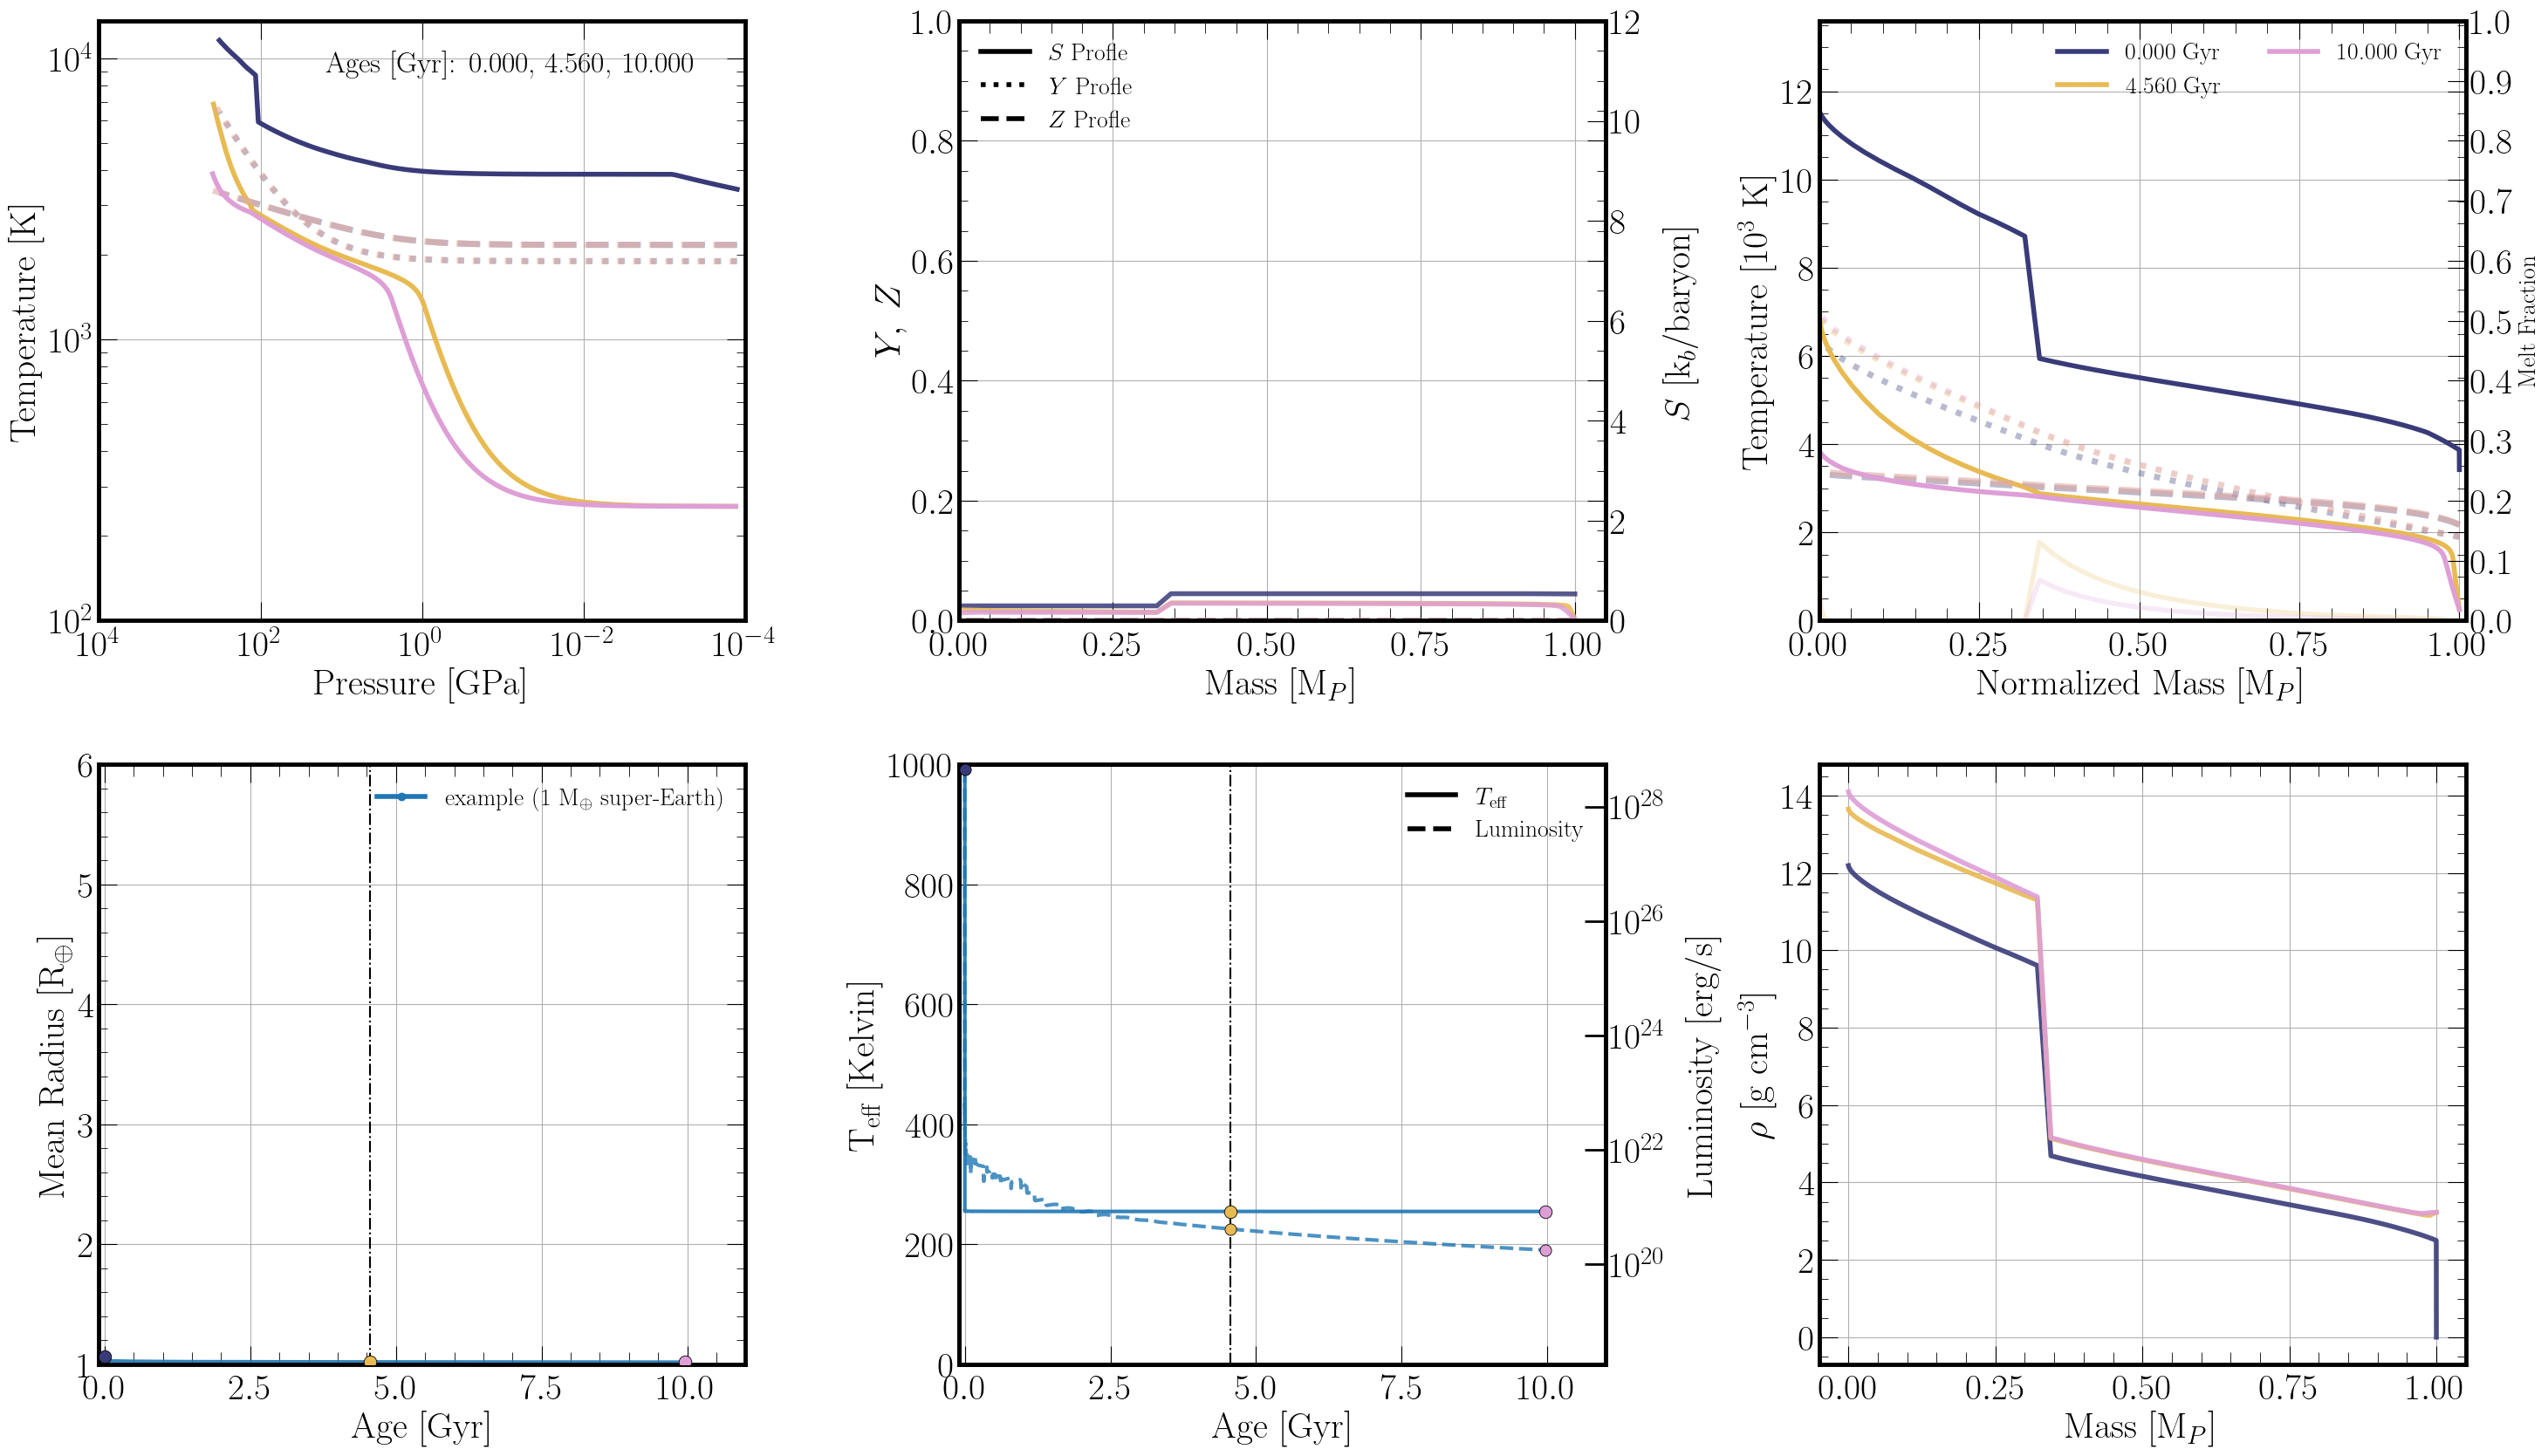

In [8]:
import plot_class

paths = [
    'parameter_examples/parameter_user_super_earth_1Mearth_bare_example.ini',

]

init = plot_class.init_plot(paths = paths,
            plot_rock_phases=True,
)

# specify legend labels for each model (in order of paths list)
labels = [
    r'example (1 M$_\oplus$ super-Earth)',
]

init.age_plot(
    ages=[0.0, 4.56, 10.0], # input ages to plot (in Gyr)
    output_file='age_compare',
    labels=labels,
    save=False,
    leg_size=20,
    rad_temp_plot=False,
    panel_num=6,
    cmap='tab20b'
)

**NOTE**: Interestingly in these exercises, only $\sim$1 Earth mass planets have low enough central pressures to start with liquid cores and evolve to have solid iron inner cores. Given the steepness of the iron solidus used here, the cores of the rest of these examples are too high in pressure to start or ever be liquid.

**NOTE**: This planet cooled too quickly to maintain a liquid outer core at 4.56 Gyrs. We are not trying to match the interior Earth conditions in this section, but to do so, we must adjust the core EOS and provide a somewhat thin envelope (see thin envelope section) to control the cooling of the entire structure. 

We compare the evolution with that of a 3 Earth mass model next.

## 1 vs. 3 M$_\oplus$ comparison

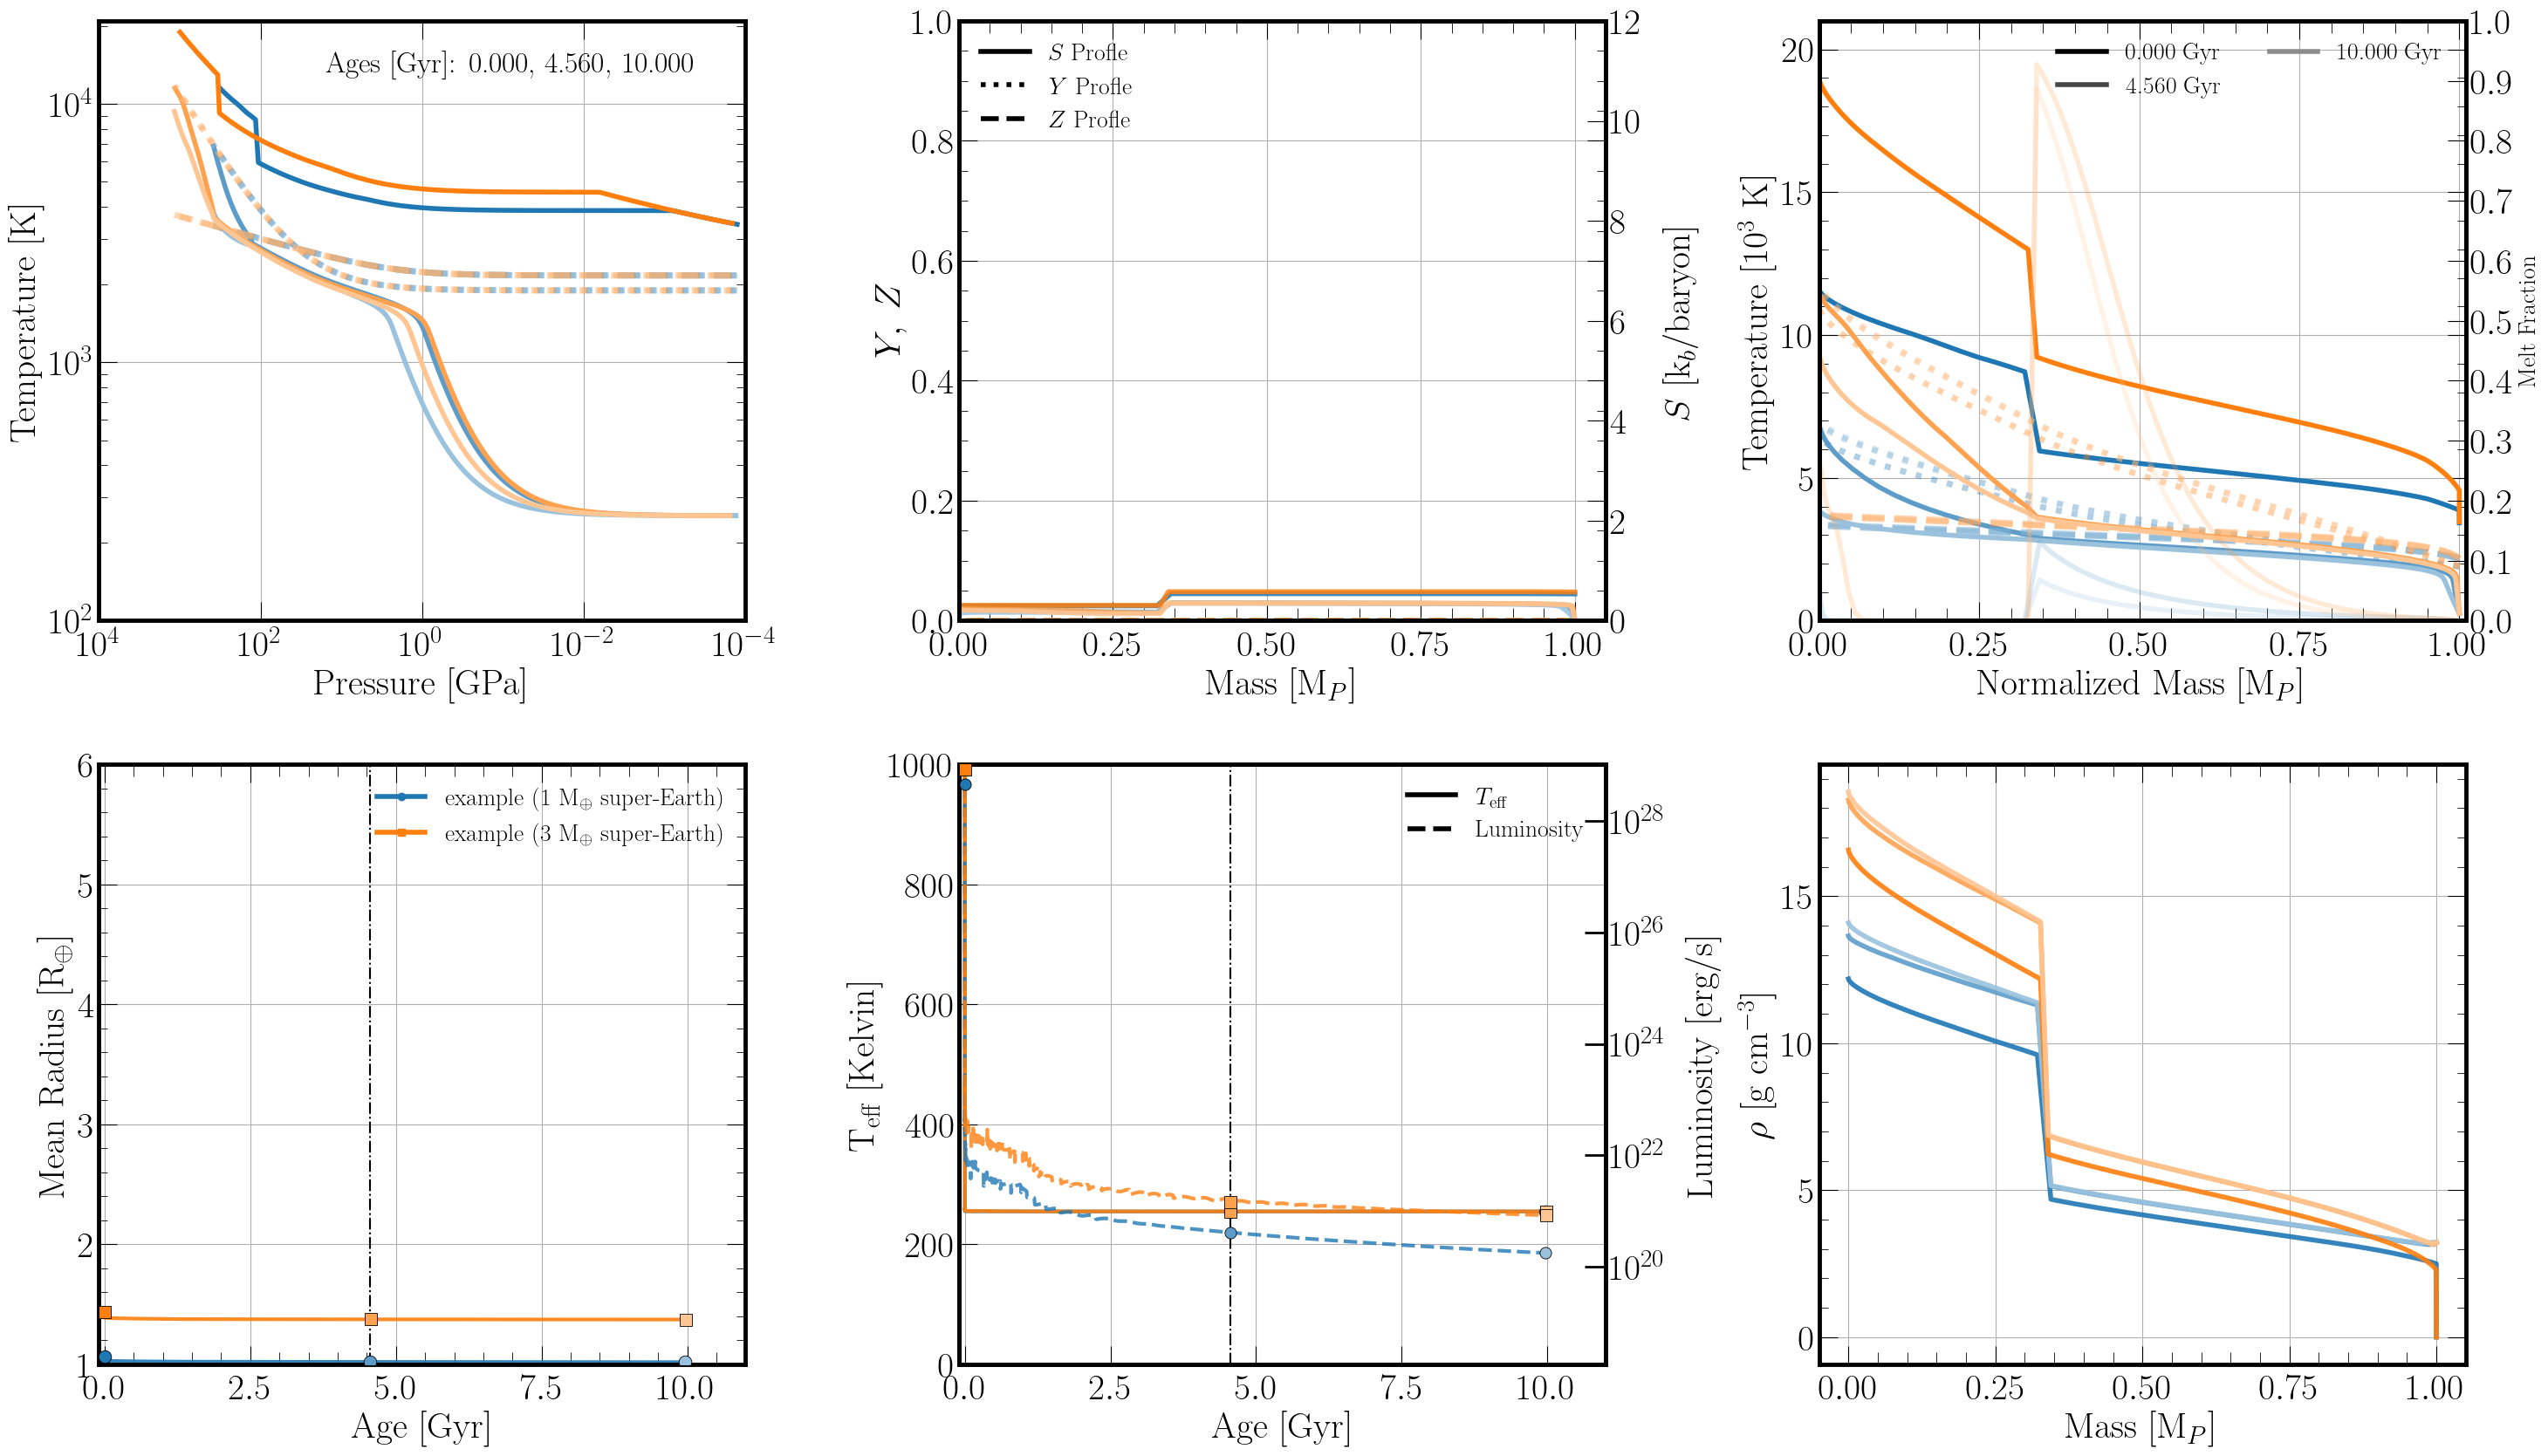

In [9]:
import plot_class

paths = [
    'parameter_examples/parameter_user_super_earth_1Mearth_bare_example.ini',
    'parameter_examples/parameter_user_super_earth_3Mearth_bare_example.ini',

]

init = plot_class.init_plot(paths = paths,
            plot_rock_phases=True,
)

# specify legend labels for each model (in order of paths list)
labels = [
    r'example (1 M$_\oplus$ super-Earth)',
    r'example (3 M$_\oplus$ super-Earth)',
]

init.age_plot(
    ages=[0.0, 4.56, 10], # input ages to plot (in Gyr)
    output_file='age_compare',
    labels=labels,
    save=False,
    leg_size=20,
    rad_temp_plot=False,
    panel_num=6,
)

Both the 1 and 3 Earth mass models begin at roughly the same temperature (solid lines in temperature plots). Recall that in mass space, the pressures are shifted inwards for more massive planets (refer to the logT vs. logP plot in the upper left corner). Due to the higher pressures in the 3 Earth mass model, its core begins under the melting point of iron. On the other hand, the 1 Earth mass model's core begins higher than its local melting temperature even though its temperature is the 3 Earth mass model core. 

## 5 M$_\oplus$ model

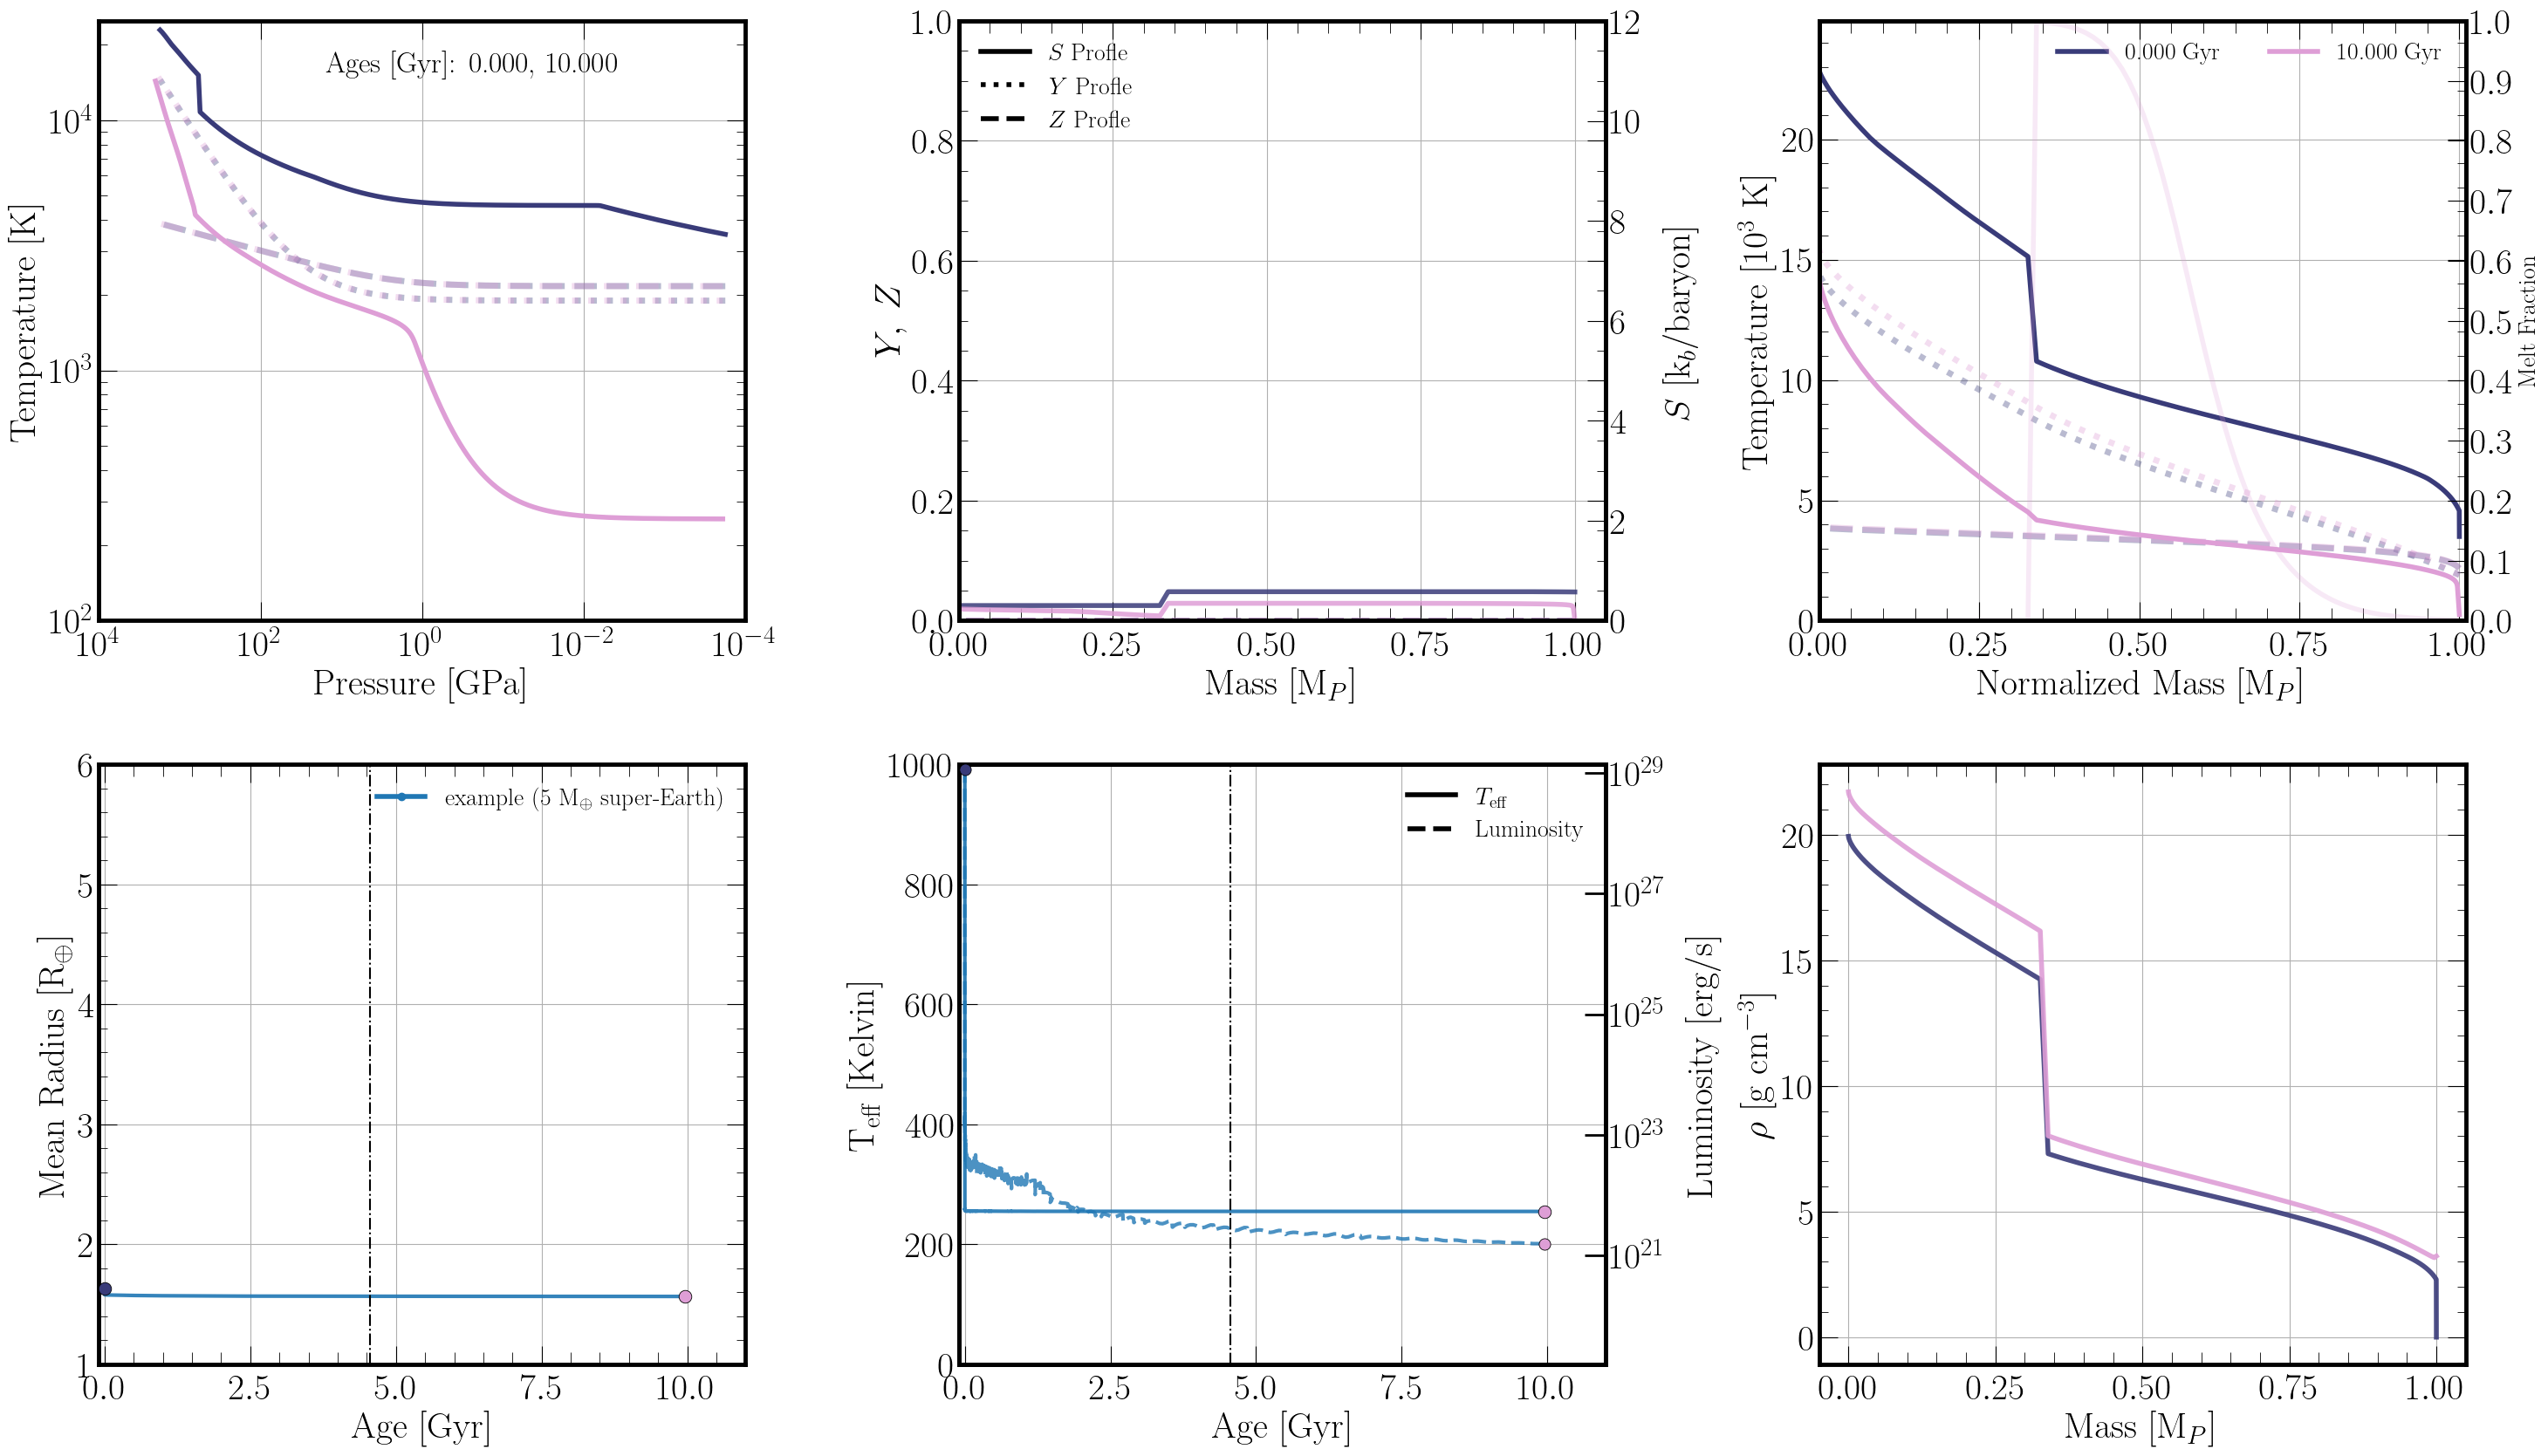

In [10]:
import plot_class

paths = [
    'parameter_examples/parameter_user_super_earth_5Mearth_bare_example.ini',
]

init = plot_class.init_plot(paths = paths,
            plot_rock_phases=True,
)

# specify legend labels for each model (in order of paths list)
labels = [
    r'example (5 M$_\oplus$ super-Earth)',
]

init.age_plot(
    ages=[0.0, 10], # input ages to plot (in Gyr)
    output_file='age_compare',
    labels=labels,
    save=False,
    leg_size=20,
    rad_temp_plot=False,
    panel_num=6,
    cmap='tab20b'
)

## 10 M$_\oplus$ model

**NOTE**: The mantle entropies need to be adjusted because higher planet masses lead to higher internal pressures. At the same entropies and higher masses, the pressures and temperatures can exceed the bounds of the equations of state. This means we need to lower the initial entropy to model higher mass planets to obtain reasonable interior temperatures

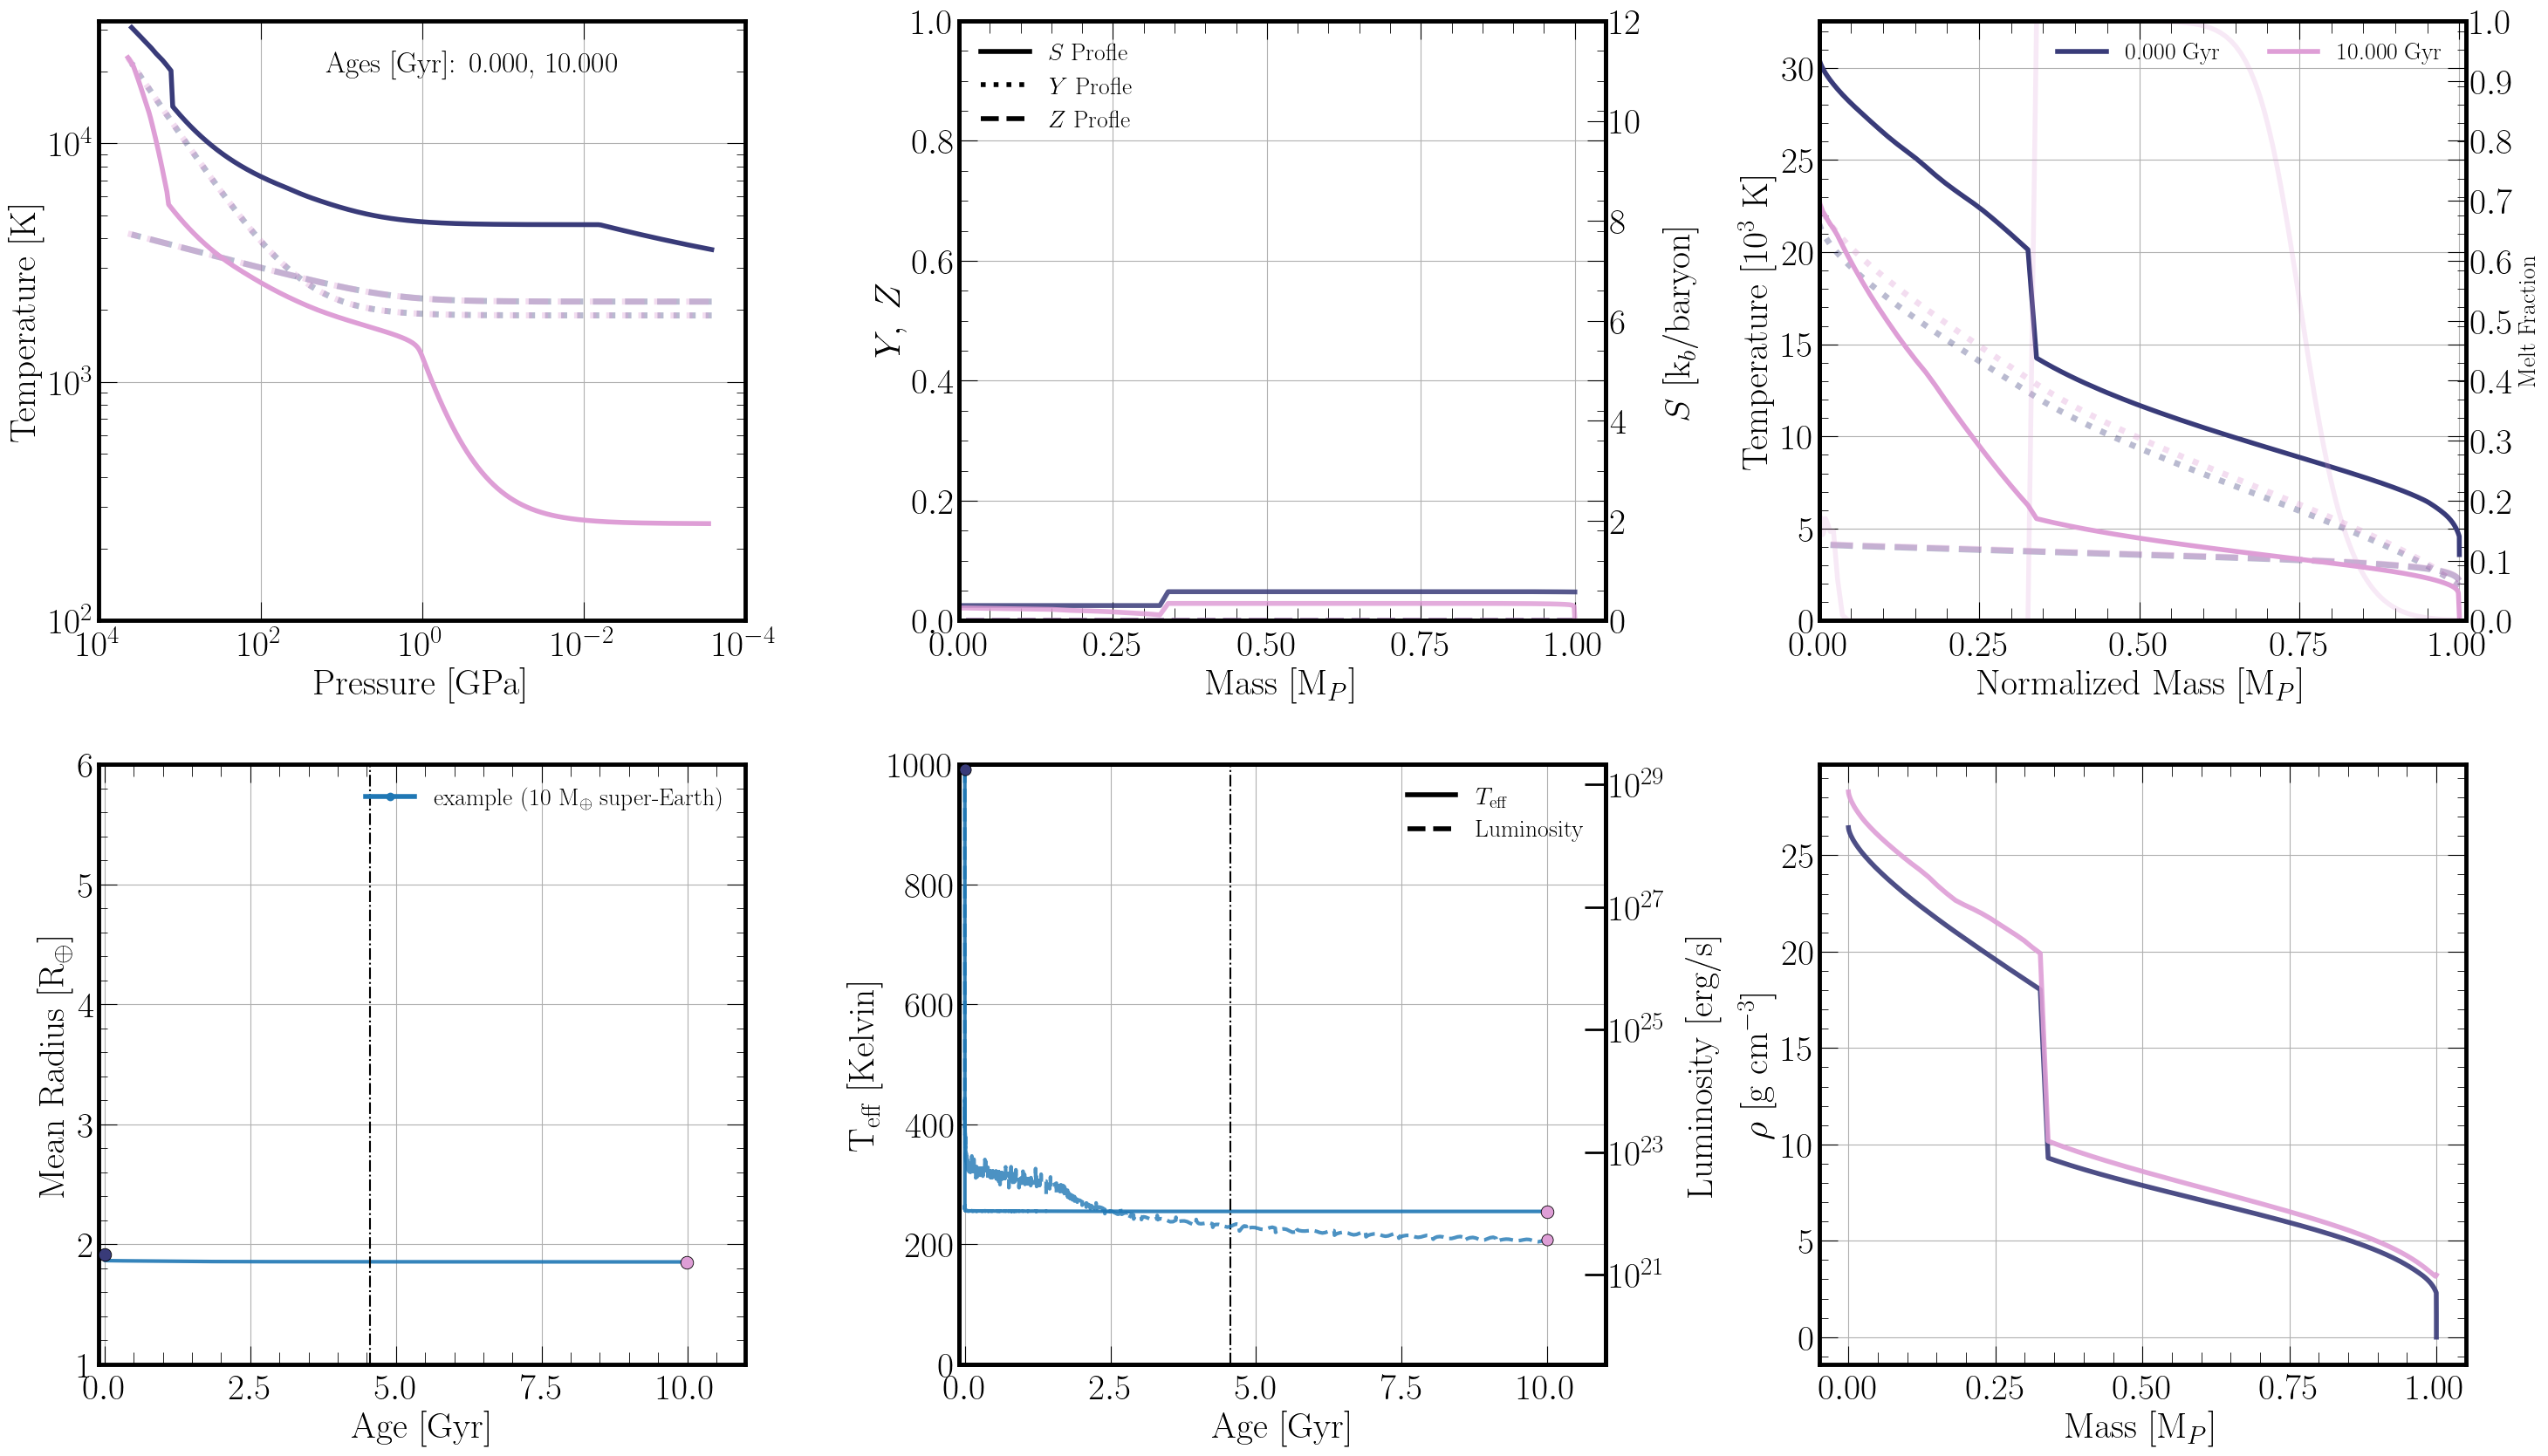

In [11]:
import plot_class

paths = [
    'parameter_examples/parameter_user_super_earth_10Mearth_bare_example.ini',

]

init = plot_class.init_plot(paths = paths,
            plot_rock_phases=True,
)

# specify legend labels for each model (in order of paths list)
labels = [
    r'example (10 M$_\oplus$ super-Earth)',
]

init.age_plot(
    ages=[0.0, 10.0], # input ages to plot (in Gyr)
    output_file='age_compare',
    labels=labels,
    save=False,
    leg_size=20,
    rad_temp_plot=False,
    panel_num=6,
    cmap='tab20b'
)

# Super-Earth mass-radius (M-R) relation example

Compare the plot below with Figure 1 of Lopez & Fortney (2014). In that panel, they plot the no envelope case with a brown dashed line. It starts at 1 Earth radius for a 1 Earth mass planet, and peaks at approximately 2 Earth radii for a 20 Earth mass model. The plot below shows a similar behavior.

I did this exercise for sub-Neptunes (Tejada Arevalo et al. 2026a) and found a similar M-R relation for sub-Neptunes, closely reproducing the middle panel of their Figure 1. 

I will run the following half Earth mass parameter to get a broader view below 1 Earth mass (also provided):

`parameter_examples/parameter_user_super_earth_0.5Mearth_bare_example.ini`

In [12]:
import load_models
from utils import const

paths = [
    'parameter_examples/parameter_user_super_earth_0.5Mearth_bare_example.ini',
    'parameter_examples/parameter_user_super_earth_1Mearth_bare_example.ini',
    'parameter_examples/parameter_user_super_earth_3Mearth_bare_example.ini',
    'parameter_examples/parameter_user_super_earth_5Mearth_bare_example.ini',
    'parameter_examples/parameter_user_super_earth_10Mearth_bare_example.ini',

]

models = load_models.load(paths)

Reading files...
Finished reading files...


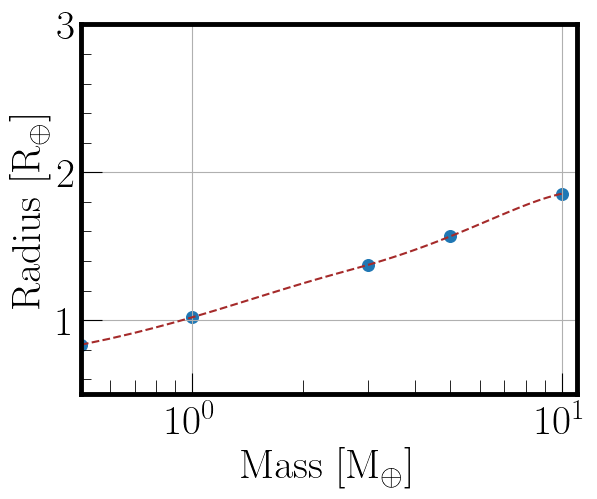

In [13]:
radius_final = [models[i]['data_rad'][-1]/const.rearth for i in range(len(paths))]
masses = [models[i]['mass_grid'][0]/const.mearth for i in range(len(paths))]

import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

r_M = interp1d(masses, radius_final, kind='cubic', fill_value='extrapolate') # simple cubic interpolation for demonstration purposes only

masses_interp = np.linspace(0.5, 10.0, 100)
radius_interp = r_M(masses_interp)


plt.scatter(masses, radius_final, s=70)
plt.plot(masses_interp, radius_interp, label='Cubic Interpolation', color='brown', ls='--')
plt.xscale('log')
plt.xlabel(r'Mass [M$_\oplus$]')
plt.ylabel(r'Radius [R$_\oplus$]')
plt.minorticks_on()
plt.xlim(0.5, 11)
plt.ylim(0.5, 3.0)
plt.show()


# Compare M-R relations from previous section

In [14]:
import load_models
from utils import const

paths_nothinenvs = [
    'parameter_examples/parameter_user_super_earth_0.5Mearth_bare_example.ini',
    'parameter_examples/parameter_user_super_earth_1Mearth_bare_example.ini',
    'parameter_examples/parameter_user_super_earth_3Mearth_bare_example.ini',
    'parameter_examples/parameter_user_super_earth_5Mearth_bare_example.ini',
    'parameter_examples/parameter_user_super_earth_10Mearth_bare_example.ini',

]

paths_thinenvs = [
    'parameter_examples/parameter_user_super_earth_0.5Mearth_thinenv_example.ini',
    'parameter_examples/parameter_user_super_earth_1Mearth_thinenv_example.ini',
    'parameter_examples/parameter_user_super_earth_3Mearth_thinenv_example.ini',
    'parameter_examples/parameter_user_super_earth_5Mearth_thinenv_example.ini',
    'parameter_examples/parameter_user_super_earth_10Mearth_thinenv_example.ini',

]
models_nothinenvs = load_models.load(paths_nothinenvs)
models_thinenvs = load_models.load(paths_thinenvs)

Reading files...
Finished reading files...
Reading files...
Finished reading files...


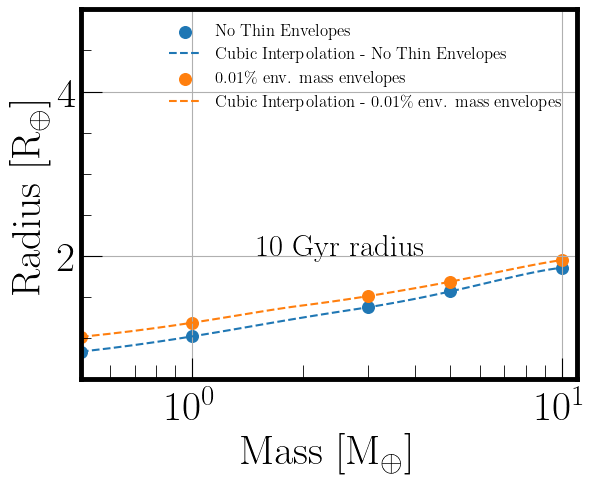

In [15]:
radius_final_nothinenvs = [models_nothinenvs[i]['data_rad'][-1]/const.rearth for i in range(len(paths_nothinenvs))]
masses_nothinenvs = [models_nothinenvs[i]['mass_grid'][0]/const.mearth for i in range(len(paths_nothinenvs))]

radius_final_thinenvs = [models_thinenvs[i]['data_rad'][-1]/const.rearth for i in range(len(paths_thinenvs))]
masses_thinenvs = [models_thinenvs[i]['mass_grid'][0]/const.mearth for i in range(len(paths_thinenvs))]

import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

r_M_nothinenvs = interp1d(masses_nothinenvs, radius_final_nothinenvs, kind='cubic', fill_value='extrapolate') # simple cubic interpolation for demonstration purposes only
r_M_thinenvs = interp1d(masses_thinenvs, radius_final_thinenvs, kind='quadratic', fill_value='extrapolate') # simple cubic interpolation for demonstration purposes only

masses_interp_nothinenvs = np.linspace(0.5, 10.0, 100)
radius_interp_nothinenvs = r_M_nothinenvs(masses_interp_nothinenvs)

masses_interp_thinenvs = np.linspace(0.5, 10.0, 100)
radius_interp_thinenvs = r_M_thinenvs(masses_interp_thinenvs)


plt.scatter(masses_nothinenvs, radius_final_nothinenvs, s=70, label='No Thin Envelopes')
plt.plot(masses_interp_nothinenvs, radius_interp_nothinenvs, label='Cubic Interpolation - No Thin Envelopes', color='C0', ls='--')
plt.scatter(masses_thinenvs, radius_final_thinenvs, s=70, label='0.01\% env. mass envelopes')
plt.plot(masses_interp_thinenvs, radius_interp_thinenvs, label='Cubic Interpolation - 0.01\% env. mass envelopes', color='C1', ls='--')
plt.xscale('log')
plt.xlabel(r'Mass [M$_\oplus$]')
plt.ylabel(r'Radius [R$_\oplus$]')
plt.legend(frameon=False, fontsize=12)
plt.text(1.5, 2.0, '10 Gyr radius', color='k', fontsize=22)
plt.minorticks_on()
plt.xlim(0.5, 11)
plt.ylim(0.5, 5.0)
plt.show()


**NOTE**: The thin envelope M-R relation is rather unusual, to put it mildly. To lower the radii, try lowering the IR opacity and either tune down the convective overshoot cap, or turn it off all together. This will also depend on the boundary condition used. If you increase the envelope metallicity (`Z_ini`), the radius should also decrease. If you then use `bc_atm = f07`, the radius should also decrease so that the M-R slope is positive at low, terrestrial masses.

# Conclusion

These exercises show the kind of modeling you can do with ORCHARD. We've provided here various examples of sub-Neptune and super-Earth evolution, and shown that even very thin (~0.01% by mass) envelopes can make a 10-20% difference in the radius evolution for the same mass of planet.

Of course, we've applied an artificial "overshoot" parameter here to let more heat out of the mantle and core, which keeps the thin envelopes hotter for the duration of the evolution.

You can choose to not have any eddy overshoot (`eddy_overshoot = False`). This will cool the thin envelopes more, but keep the mantles and cores hotter.
Comparing the radii from no overshoot with those shown here is left as an exercise to the reader.